In [3]:
from pathlib import Path
import shutil
import time

def clean_xpidon_outputs(
    project_root=".",
    backup=True,
    dry_run=True,
):
    """
    Clean old XPIDON training outputs before a new notebook training run.

    Use this BEFORE training.
    Do NOT run this after training and before plotting, otherwise models/loss files will be deleted.

    Parameters
    ----------
    project_root : str
        Project root path. Usually "." if notebook is opened inside XPIDON-Composites.
    backup : bool
        If True, backup current outputs/ and root-level model pkl files before cleaning.
    dry_run : bool
        If True, only print what would be deleted. Set False to actually clean.
    """

    root = Path(project_root).resolve()

    # Safety check: avoid deleting files from wrong directory
    expected_files = ["main.py", "phy_params.json", "exp_params.json", "train_params.json"]
    existing_expected = [f for f in expected_files if (root / f).exists()]

    if len(existing_expected) < 2:
        raise RuntimeError(
            f"Project root may be wrong: {root}\n"
            "Please run this from XPIDON-Composites project root or set project_root correctly."
        )

    print(f"Project root: {root}")
    print(f"Dry run: {dry_run}")
    print(f"Backup: {backup}")

    # Folders gengerated by training/plotting
    output_subdirs = [
        root / "outputs" / "models",
        root / "outputs" / "loss_data",
        root / "outputs" / "figures",
        root / "outputs" / "predictions",
    ]

    # Root-level files generated by train.py
    root_patterns = [
        "xpidon_class_*_T.pkl",
        "xpidon_class_*_a.pkl",
        "T_temp.pkl",
        "a_temp.pkl",
    ]

    files_to_delete = []
    dirs_to_clean = []

    for folder in output_subdirs:
        folder.mkdir(parents=True, exist_ok=True)
        dirs_to_clean.append(folder)
        for item in folder.iterdir():
            files_to_delete.append(item)

    for pattern in root_patterns:
        files_to_delete.extend(root.glob(pattern))

    files_to_delete = sorted(set(files_to_delete))

    print("\nFiles/folders that will be cleaned:")
    if not files_to_delete:
        print("  Nothing to clean.")
    else:
        for p in files_to_delete:
            print(" ", p.relative_to(root))

    if dry_run:
        print("\nDry run only. Nothing was deleted.")
        print("Run clean_xpidon_outputs(dry_run=False) to actually clean.")
        return

    # Optional backup
    if backup and files_to_delete:
        timestamp = time.strftime("%Y%m%d_%H%M%S")
        backup_dir = root / f"outputs_backup_{timestamp}"
        backup_dir.mkdir(parents=True, exist_ok=True)

        print(f"\nCreating backup: {backup_dir.name}")

        # Backup outputs folder
        outputs_dir = root / "outputs"
        if outputs_dir.exists():
            shutil.copytree(outputs_dir, backup_dir / "outputs", dirs_exist_ok=True)

        # Backup root pkl files
        root_pkl_backup = backup_dir / "root_pkl_files"
        root_pkl_backup.mkdir(exist_ok=True)

        for pattern in root_patterns:
            for file in root.glob(pattern):
                if file.is_file():
                    shutil.copy2(file, root_pkl_backup / file.name)

    # Delete contents
    for p in files_to_delete:
        if p.exists():
            if p.is_file() or p.is_symlink():
                p.unlink()
            elif p.is_dir():
                shutil.rmtree(p)

    # Recreate output folders
    for folder in output_subdirs:
        folder.mkdir(parents=True, exist_ok=True)

    print("\nClean complete.")

In [4]:
clean_xpidon_outputs(dry_run=True)

Project root: /Users/luzhang/Projects/XPIDON-Composites
Dry run: True
Backup: True

Files/folders that will be cleaned:
  T_temp.pkl
  a_temp.pkl

Dry run only. Nothing was deleted.
Run clean_xpidon_outputs(dry_run=False) to actually clean.


In [5]:
clean_xpidon_outputs(dry_run=False, backup=True)

Project root: /Users/luzhang/Projects/XPIDON-Composites
Dry run: False
Backup: True

Files/folders that will be cleaned:
  T_temp.pkl
  a_temp.pkl

Creating backup: outputs_backup_20260714_044910

Clean complete.


In [6]:
from utils.phy_params import PhyParams
from utils.exp_params import ExpParams
from utils.train_params import TrainParams
from utils.air_temp import Temp_air
from utils.data_utils import DataGenerator, generate_training_data
from trainer.train import train
from models.pidon import XPIDON
from loss.loss import XPIDONLoss

Platform 'METAL' is experimental and not all JAX functionality may be correctly supported!


Metal device set to: Apple M4 Pro

systemMemory: 24.00 GB
maxCacheSize: 8.00 GB



W0000 00:00:1783968550.709750  941125 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1783968550.724036  941125 service.cc:145] XLA service 0x326713300 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1783968550.724197  941125 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1783968550.725366  941125 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1783968550.725376  941125 mps_client.cc:384] XLA backend will use up to 17179410432 bytes on device 0 for SimpleAllocator.


In [ ]:
params = PhyParams('phy_params.json')
exp_params = ExpParams('exp_params.json')
train_params = TrainParams('train_params.json')
init_sub_domain = 5
Tolerance_level =  5e-3
m_inp = 9
branch_layers = [m_inp, 50, 50, 50, 100]
trunk_layers =  [2, 50, 50, 50, 50, 50, 100]
nomad_layers_T = [100, 50, 50, 50, 50, 1]

: 


--- Processing Sub-domain: 1/5 ---
Time range: 0.00 to 3760.00 seconds
First subdomain: using initial model parameters.


Training Progress:   7%|████████████▌                                                                                                                                                                   | 10/140 [04:32<59:08, 27.29s/it, Status=** Training a **, Loss T=2.81e-04, Loss a=2.23e-01, ICs T=3.76e-06, ICs tool=7.62e-06, ICs Alpha=2.23e-01, BCs Bot=3.18e-05, BCs Top=7.07e-06, PDE Part=3.18e-05, PDE Tool=2.61e-05, Cure Part=5.89e-05, INF=9.69e-06, FLUX=7.31e-06, T lr=6.56e-04, a lr=1.00e-03]

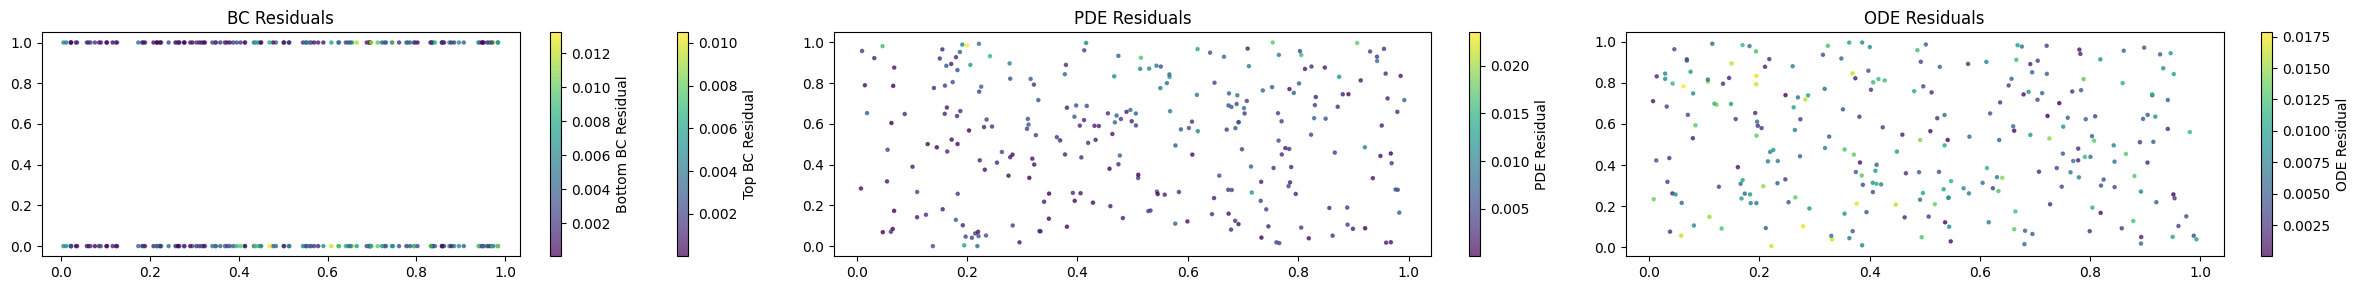

Training Progress:  14%|█████████████████████████▏                                                                                                                                                      | 20/140 [07:23<34:33, 17.28s/it, Status=** Training a **, Loss T=2.86e-04, Loss a=2.69e-05, ICs T=5.32e-06, ICs tool=7.46e-06, ICs Alpha=4.31e-09, BCs Bot=2.83e-05, BCs Top=1.22e-05, PDE Part=2.89e-05, PDE Tool=2.29e-05, Cure Part=2.69e-05, INF=9.04e-06, FLUX=1.00e-05, T lr=6.56e-04, a lr=6.56e-04]

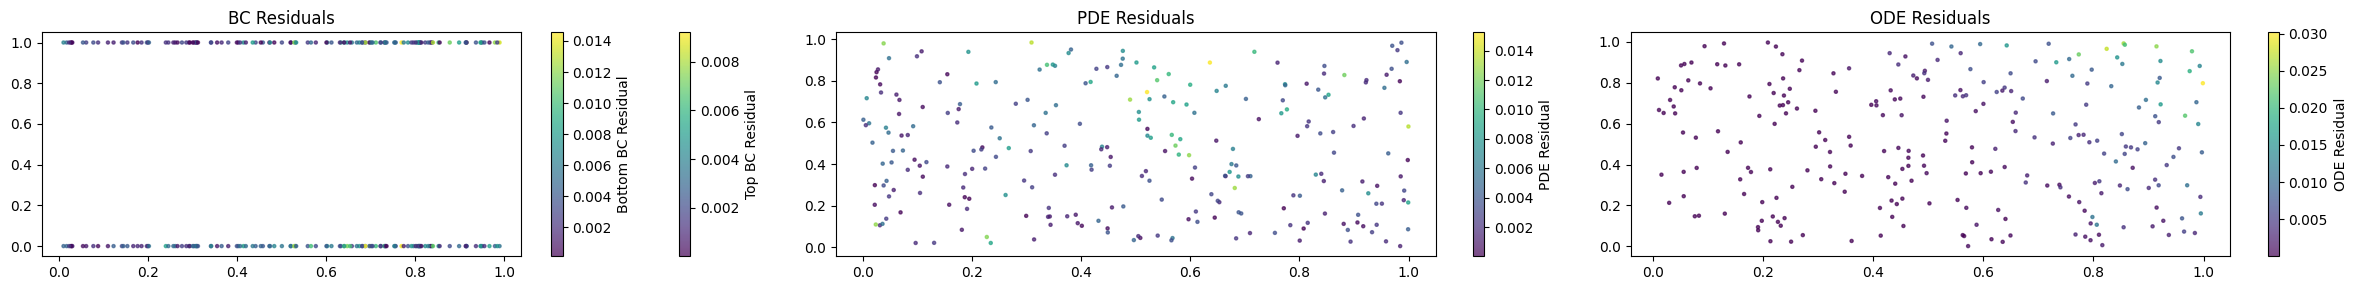

Training Progress:  21%|█████████████████████████████████████▋                                                                                                                                          | 30/140 [12:02<50:40, 27.65s/it, Status=** Training T **, Loss T=1.30e-04, Loss a=4.08e-05, ICs T=1.72e-06, ICs tool=2.39e-06, ICs Alpha=4.28e-09, BCs Bot=7.48e-06, BCs Top=1.26e-05, PDE Part=5.21e-06, PDE Tool=9.45e-06, Cure Part=4.08e-05, INF=6.87e-06, FLUX=4.51e-06, T lr=4.30e-04, a lr=6.56e-04]

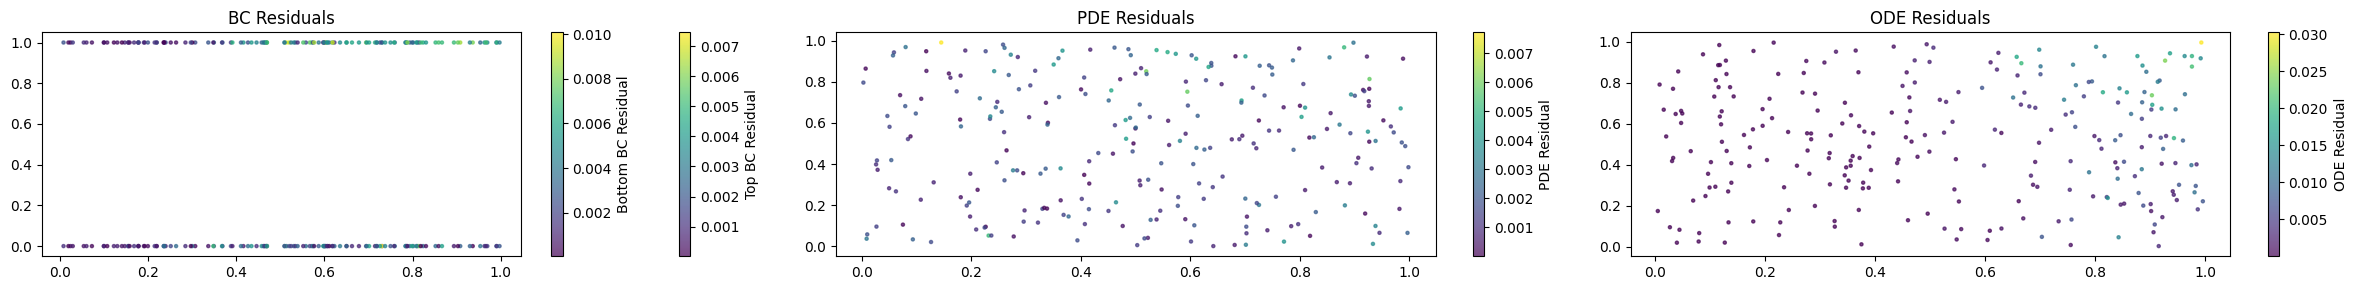

Training Progress:  29%|██████████████████████████████████████████████████▎                                                                                                                             | 40/140 [14:57<29:41, 17.82s/it, Status=** Training a **, Loss T=1.17e-04, Loss a=1.29e-07, ICs T=1.99e-06, ICs tool=2.39e-06, ICs Alpha=4.13e-09, BCs Bot=6.55e-06, BCs Top=1.17e-05, PDE Part=4.36e-06, PDE Tool=8.18e-06, Cure Part=1.25e-07, INF=3.95e-06, FLUX=4.88e-06, T lr=4.30e-04, a lr=4.30e-04]

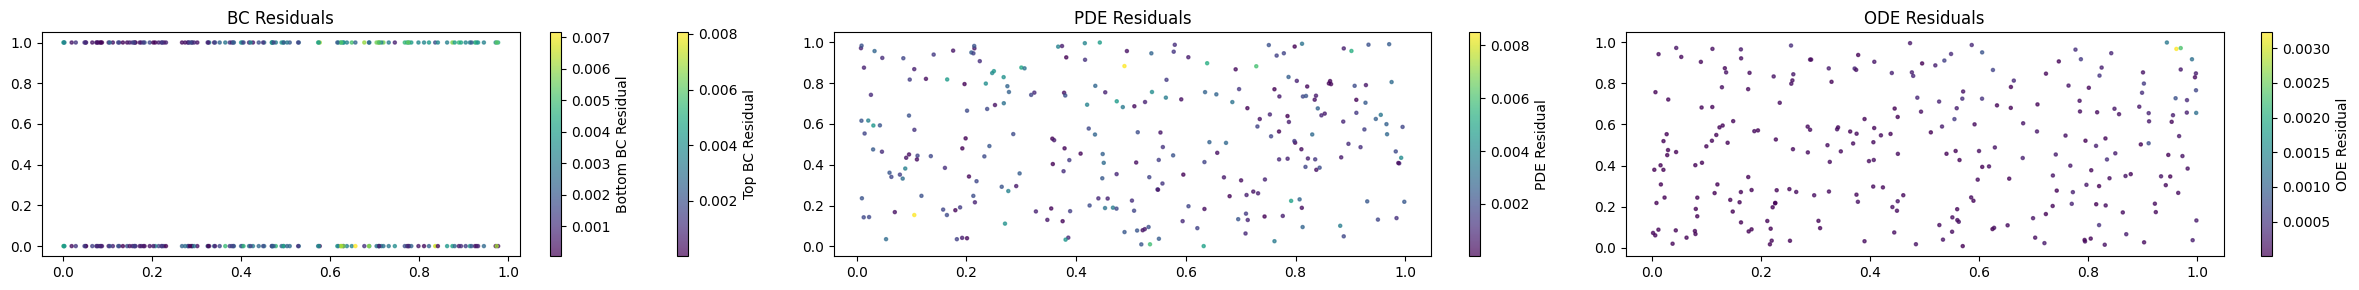

Training Progress:  36%|██████████████████████████████████████████████████████████████▊                                                                                                                 | 50/140 [19:34<41:00, 27.33s/it, Status=** Training T **, Loss T=2.35e-04, Loss a=1.93e-07, ICs T=9.71e-07, ICs tool=1.36e-06, ICs Alpha=4.09e-09, BCs Bot=4.13e-05, BCs Top=6.16e-07, PDE Part=2.41e-06, PDE Tool=6.95e-06, Cure Part=1.89e-07, INF=2.24e-06, FLUX=1.14e-05, T lr=2.82e-04, a lr=4.30e-04]

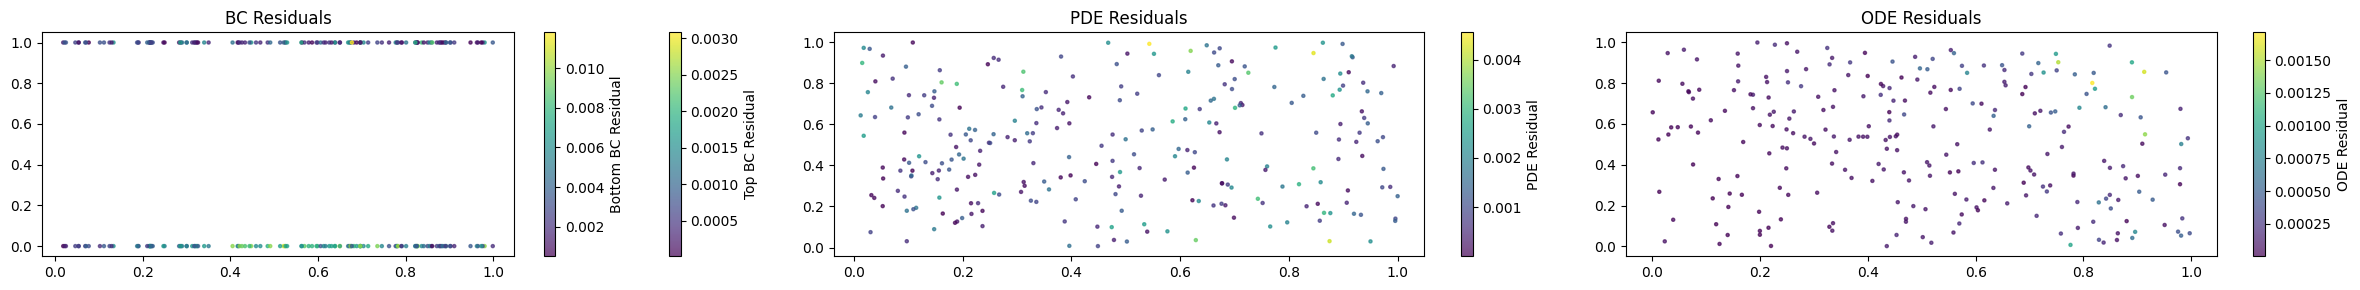

Training Progress:  43%|███████████████████████████████████████████████████████████████████████████▍                                                                                                    | 60/140 [22:26<23:07, 17.34s/it, Status=** Training a **, Loss T=2.38e-04, Loss a=2.13e-08, ICs T=9.97e-07, ICs tool=1.33e-06, ICs Alpha=1.77e-09, BCs Bot=4.08e-05, BCs Top=8.53e-07, PDE Part=5.10e-06, PDE Tool=9.49e-06, Cure Part=1.95e-08, INF=1.76e-06, FLUX=1.10e-05, T lr=2.82e-04, a lr=2.82e-04]

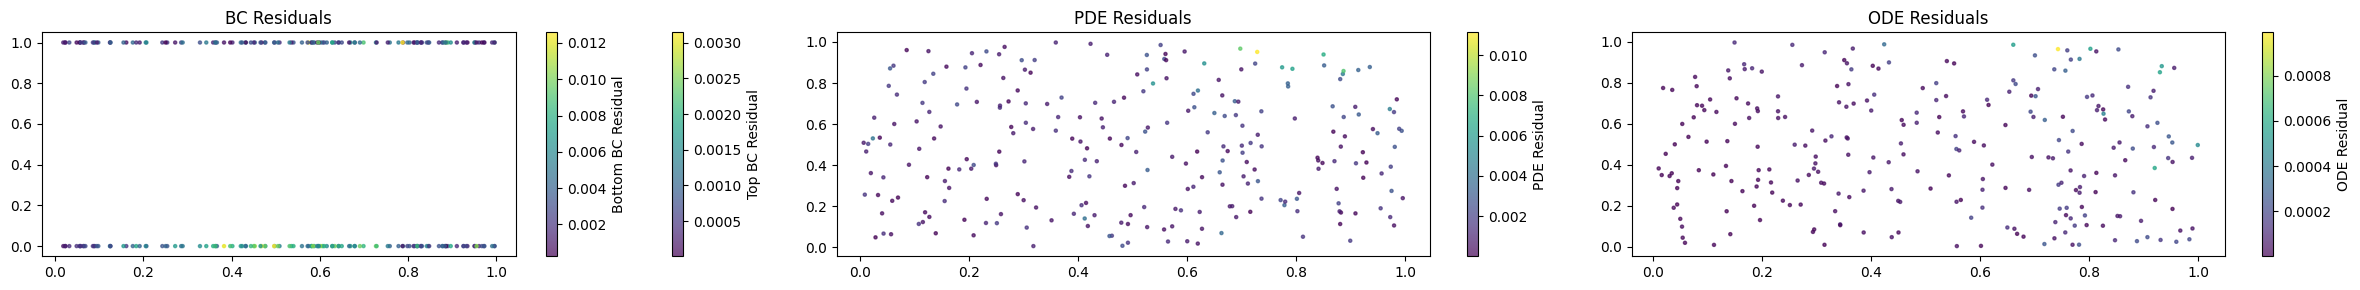

Training Progress:  50%|████████████████████████████████████████████████████████████████████████████████████████                                                                                        | 70/140 [27:08<32:38, 27.98s/it, Status=** Training T **, Loss T=6.09e-05, Loss a=1.40e-08, ICs T=6.13e-07, ICs tool=8.51e-07, ICs Alpha=1.76e-09, BCs Bot=8.96e-06, BCs Top=4.54e-07, PDE Part=2.06e-06, PDE Tool=3.43e-06, Cure Part=1.23e-08, INF=1.47e-06, FLUX=5.41e-06, T lr=1.85e-04, a lr=2.82e-04]

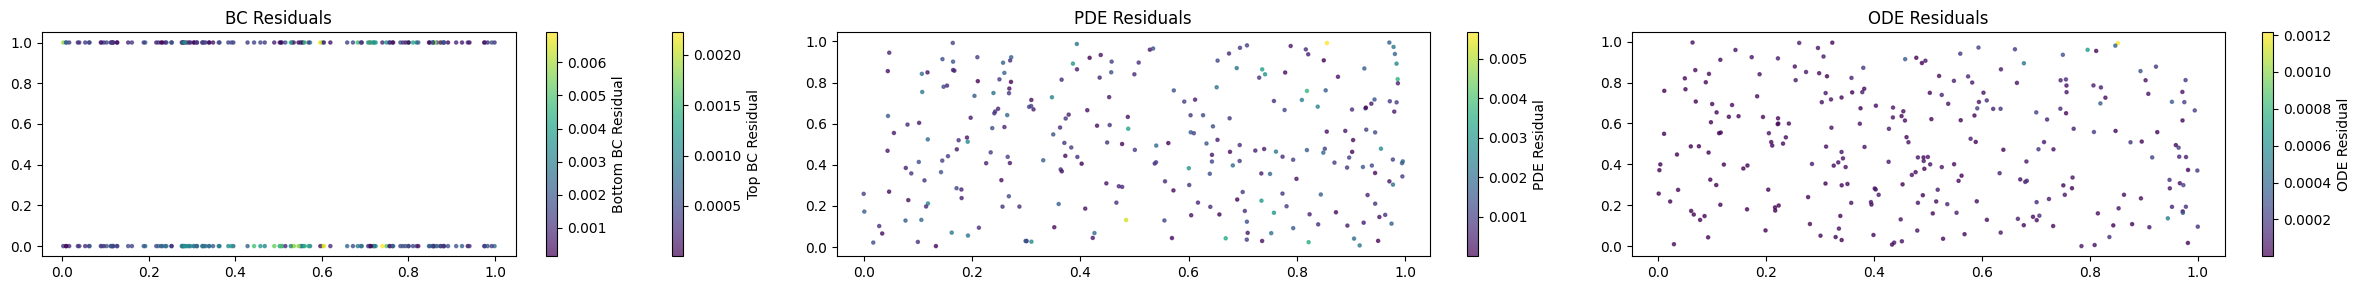

Training Progress:  57%|████████████████████████████████████████████████████████████████████████████████████████████████████▌                                                                           | 80/140 [30:03<17:44, 17.74s/it, Status=** Training a **, Loss T=4.90e-05, Loss a=1.32e-08, ICs T=7.26e-07, ICs tool=8.39e-07, ICs Alpha=1.05e-09, BCs Bot=6.75e-06, BCs Top=4.32e-07, PDE Part=2.90e-06, PDE Tool=3.45e-06, Cure Part=1.21e-08, INF=1.09e-06, FLUX=4.05e-06, T lr=1.85e-04, a lr=1.85e-04]

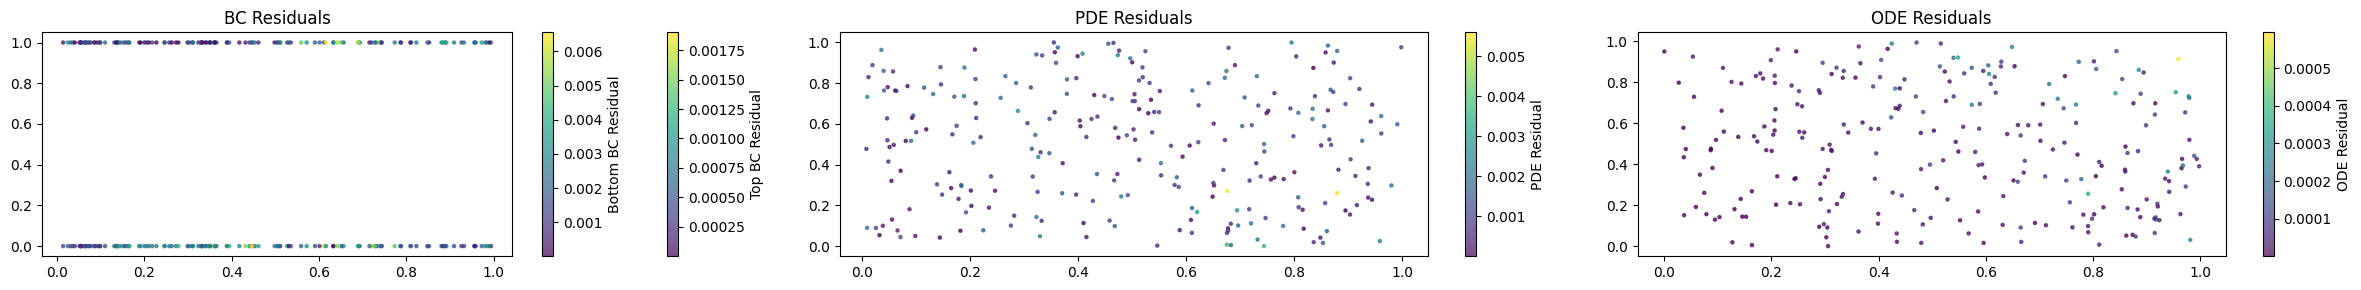

Training Progress:  64%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                                                              | 90/140 [34:44<23:13, 27.88s/it, Status=** Training T **, Loss T=1.39e-05, Loss a=3.81e-08, ICs T=4.49e-07, ICs tool=6.31e-07, ICs Alpha=1.03e-09, BCs Bot=9.58e-07, BCs Top=4.97e-07, PDE Part=1.84e-06, PDE Tool=2.55e-06, Cure Part=3.70e-08, INF=6.19e-07, FLUX=5.75e-07, T lr=1.21e-04, a lr=1.85e-04]

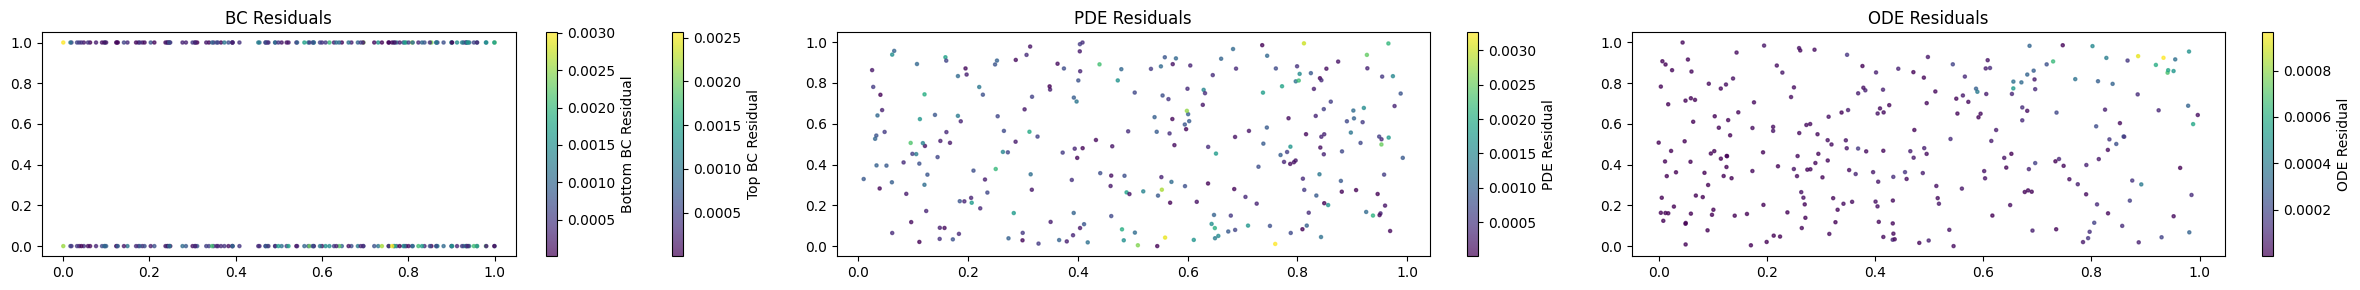

Training Progress:  71%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████                                                  | 100/140 [37:38<11:45, 17.63s/it, Status=** Training a **, Loss T=1.47e-05, Loss a=2.62e-08, ICs T=4.75e-07, ICs tool=6.28e-07, ICs Alpha=7.61e-10, BCs Bot=1.10e-06, BCs Top=6.92e-07, PDE Part=1.10e-06, PDE Tool=2.30e-06, Cure Part=2.54e-08, INF=6.71e-07, FLUX=5.64e-07, T lr=1.21e-04, a lr=1.21e-04]

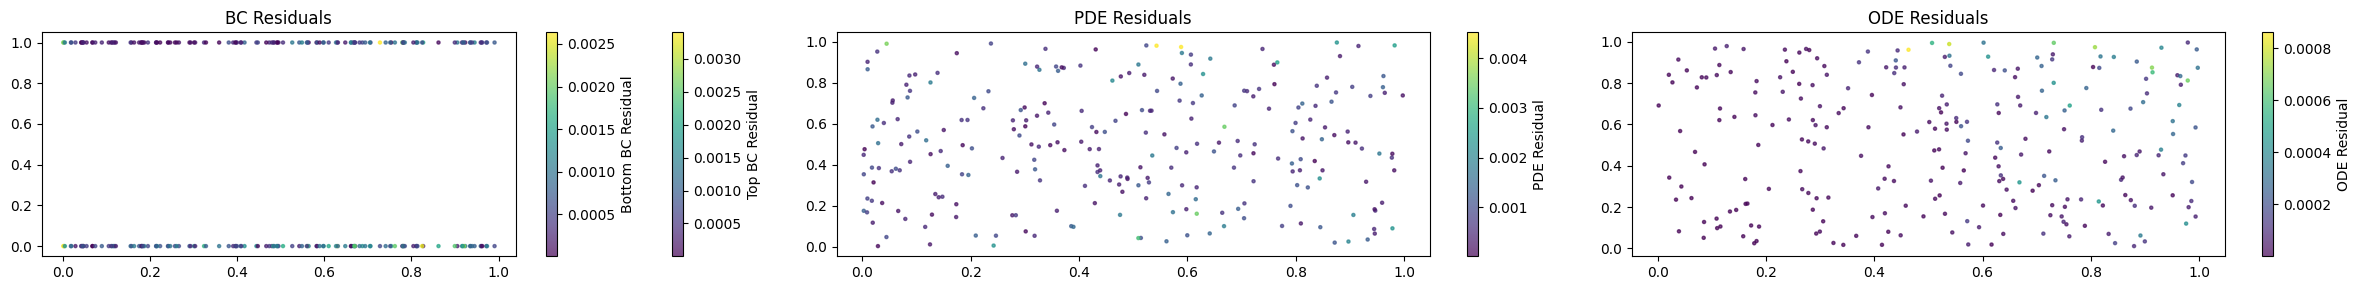

Training Progress:  79%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                                     | 110/140 [42:19<13:51, 27.72s/it, Status=** Training T **, Loss T=1.24e-05, Loss a=7.99e-08, ICs T=4.24e-07, ICs tool=5.12e-07, ICs Alpha=7.80e-10, BCs Bot=8.39e-07, BCs Top=7.61e-07, PDE Part=1.35e-06, PDE Tool=1.28e-06, Cure Part=7.91e-08, INF=4.80e-07, FLUX=3.14e-07, T lr=7.95e-05, a lr=1.21e-04]

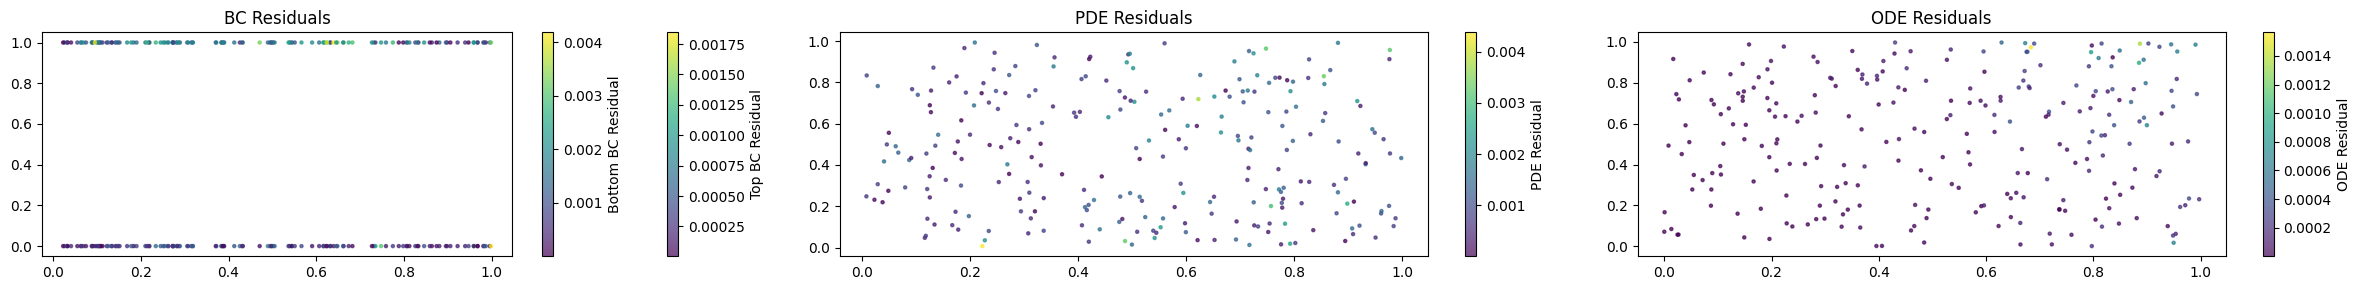

Training Progress:  86%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████                         | 120/140 [45:13<05:53, 17.65s/it, Status=** Training a **, Loss T=1.49e-05, Loss a=5.14e-09, ICs T=4.07e-07, ICs tool=4.99e-07, ICs Alpha=6.15e-10, BCs Bot=7.81e-07, BCs Top=7.59e-07, PDE Part=3.03e-06, PDE Tool=2.44e-06, Cure Part=4.53e-09, INF=4.00e-07, FLUX=3.84e-07, T lr=7.95e-05, a lr=7.95e-05]

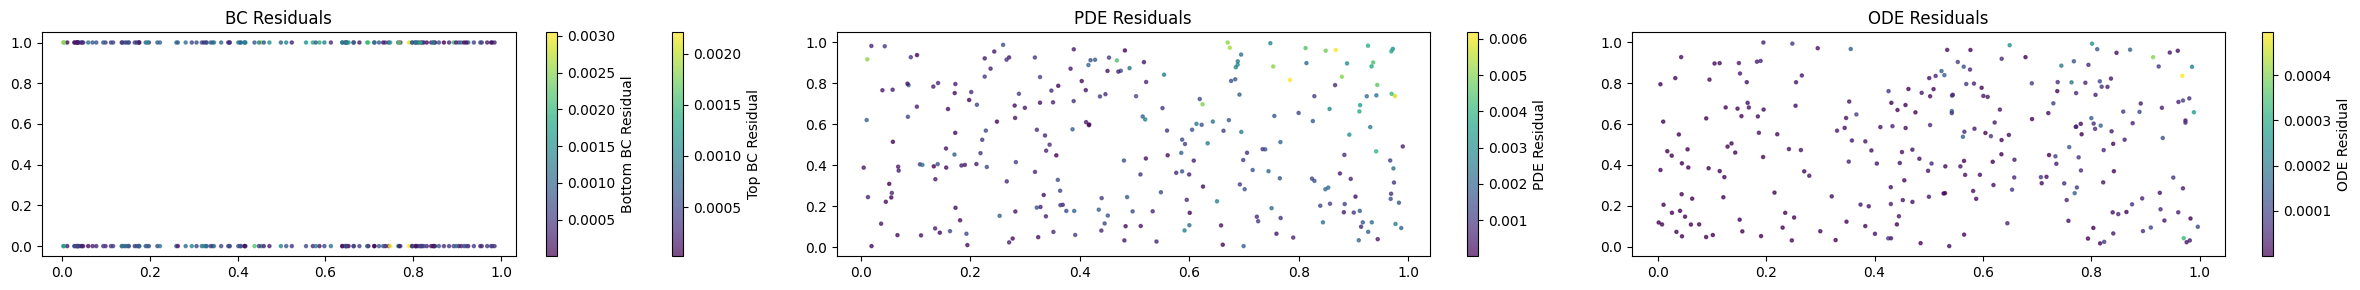

Training Progress:  93%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌            | 130/140 [49:57<04:41, 28.13s/it, Status=** Training T **, Loss T=7.10e-06, Loss a=6.23e-09, ICs T=4.22e-07, ICs tool=4.44e-07, ICs Alpha=6.40e-10, BCs Bot=3.22e-07, BCs Top=2.28e-07, PDE Part=9.72e-07, PDE Tool=1.53e-06, Cure Part=5.59e-09, INF=5.36e-07, FLUX=4.42e-07, T lr=5.21e-05, a lr=7.95e-05]

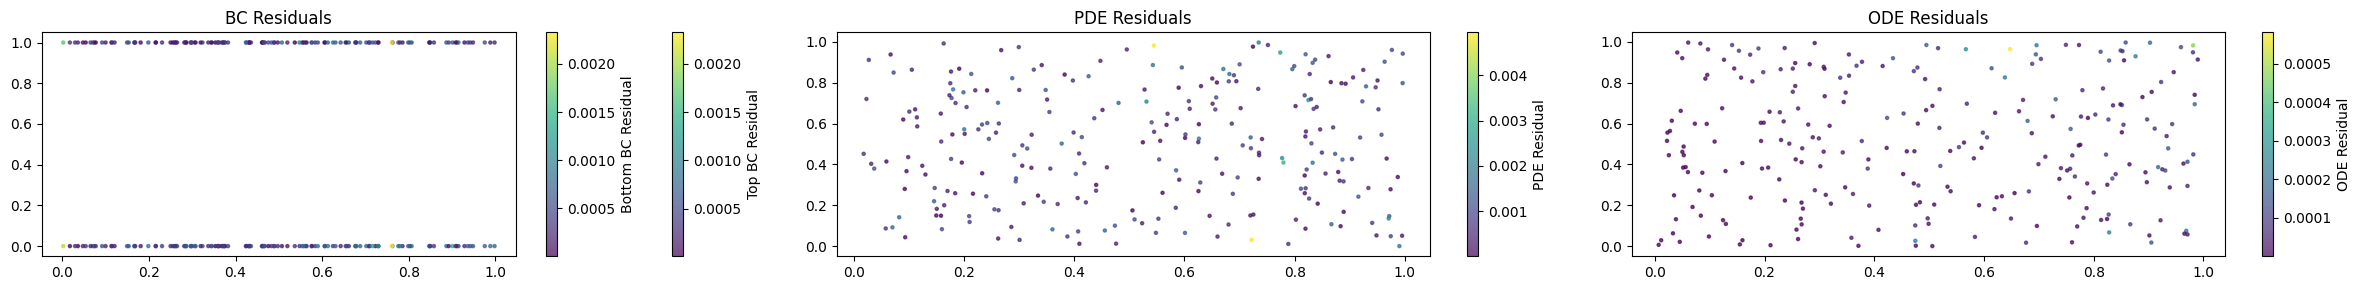

Training Progress: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 140/140 [52:53<00:00, 22.67s/it, Status=** Training a **, Loss T=7.45e-06, Loss a=4.69e-09, ICs T=3.36e-07, ICs tool=4.26e-07, ICs Alpha=5.11e-10, BCs Bot=4.17e-07, BCs Top=2.45e-07, PDE Part=9.55e-07, PDE Tool=1.48e-06, Cure Part=4.18e-09, INF=4.87e-07, FLUX=4.49e-07, T lr=5.21e-05, a lr=5.21e-05]



Subdomain converged: loss_T=7.45e-06, loss_a=4.69e-09

Model saved for subdomain 0.0000 - 0.2000
Status: converged

--- Processing Sub-domain: 2/5 ---
Time range: 3760.00 to 7520.00 seconds
Loaded pre-trained parameters from xpidon_class_02_T.pkl and xpidon_class_02_a.pkl
Loaded pre-trained parameters from xpidon_class_02_T.pkl and xpidon_class_02_a.pkl
Current subdomain initialized from previous subdomain weights.


Training Progress:   7%|████████████▍                                                                                                                                                                 | 10/140 [06:12<1:19:01, 36.47s/it, Status=** Training a **, Loss T=4.60e-04, Loss a=3.55e-03, ICs T=3.24e-06, ICs tool=1.42e-06, ICs Alpha=8.31e-06, BCs Bot=1.75e-05, BCs Top=6.62e-05, PDE Part=1.31e-05, PDE Tool=1.15e-05, Cure Part=3.54e-03, INF=1.10e-05, FLUX=1.71e-06, T lr=6.56e-04, a lr=1.00e-03]

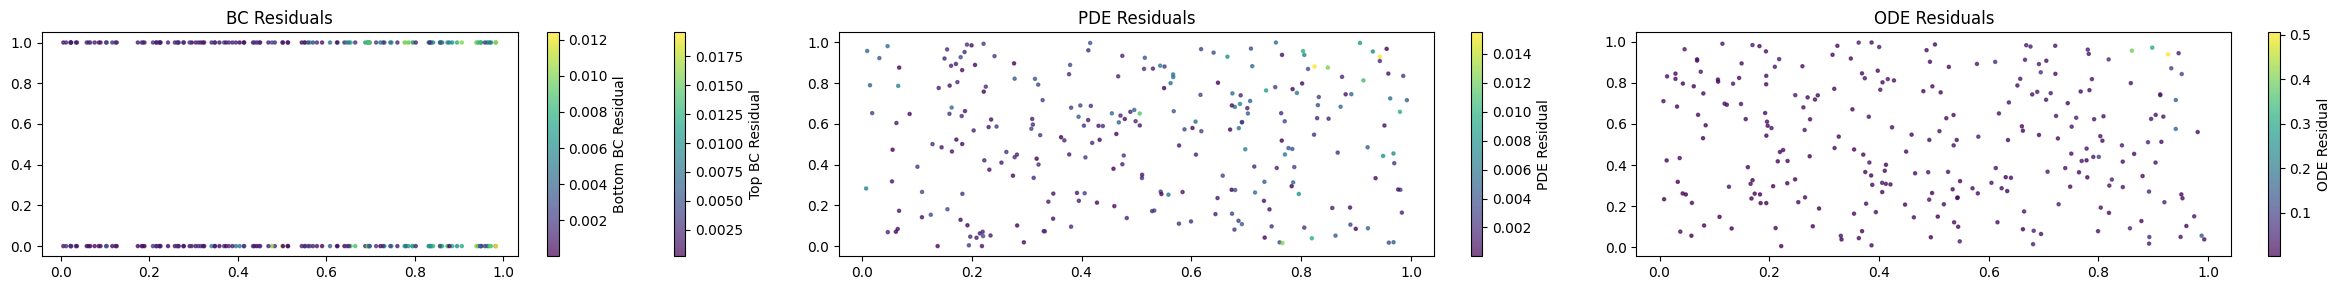

Training Progress:  14%|█████████████████████████▏                                                                                                                                                      | 20/140 [09:32<40:41, 20.34s/it, Status=** Training a **, Loss T=4.35e-04, Loss a=1.13e-04, ICs T=3.25e-06, ICs tool=1.18e-06, ICs Alpha=5.38e-06, BCs Bot=1.57e-05, BCs Top=6.36e-05, PDE Part=1.19e-05, PDE Tool=1.05e-05, Cure Part=1.08e-04, INF=9.60e-06, FLUX=2.41e-06, T lr=6.56e-04, a lr=6.56e-04]

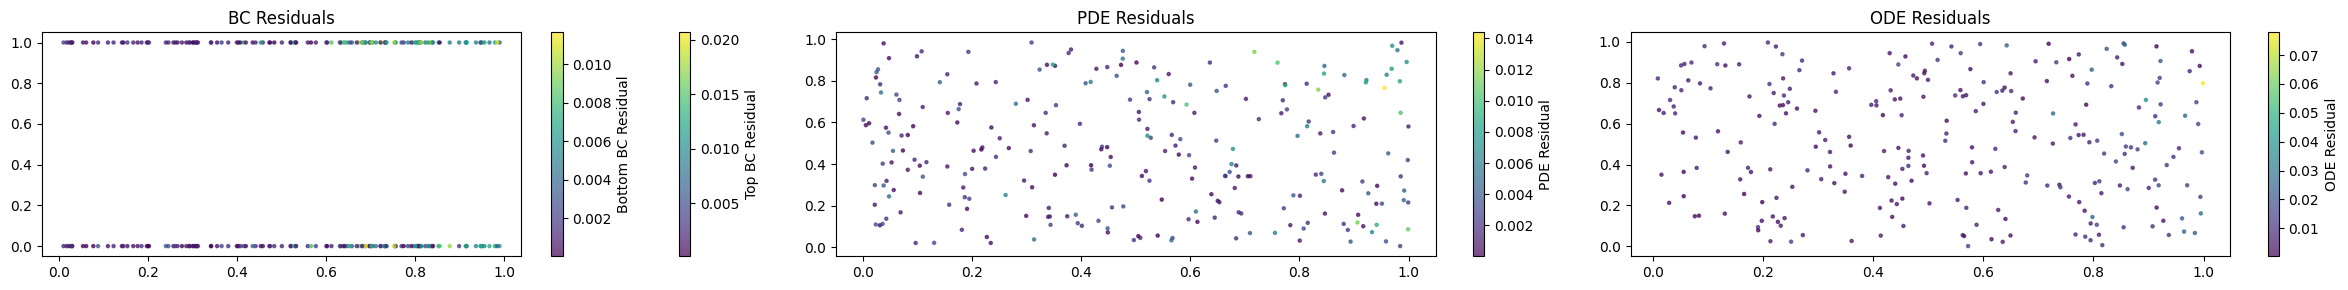

Training Progress:  21%|█████████████████████████████████████▎                                                                                                                                        | 30/140 [15:39<1:06:26, 36.24s/it, Status=** Training T **, Loss T=7.60e-05, Loss a=1.00e-03, ICs T=1.39e-06, ICs tool=2.01e-06, ICs Alpha=6.02e-06, BCs Bot=8.81e-06, BCs Top=2.61e-06, PDE Part=4.85e-06, PDE Tool=4.17e-06, Cure Part=9.95e-04, INF=4.30e-06, FLUX=2.21e-06, T lr=4.30e-04, a lr=6.56e-04]

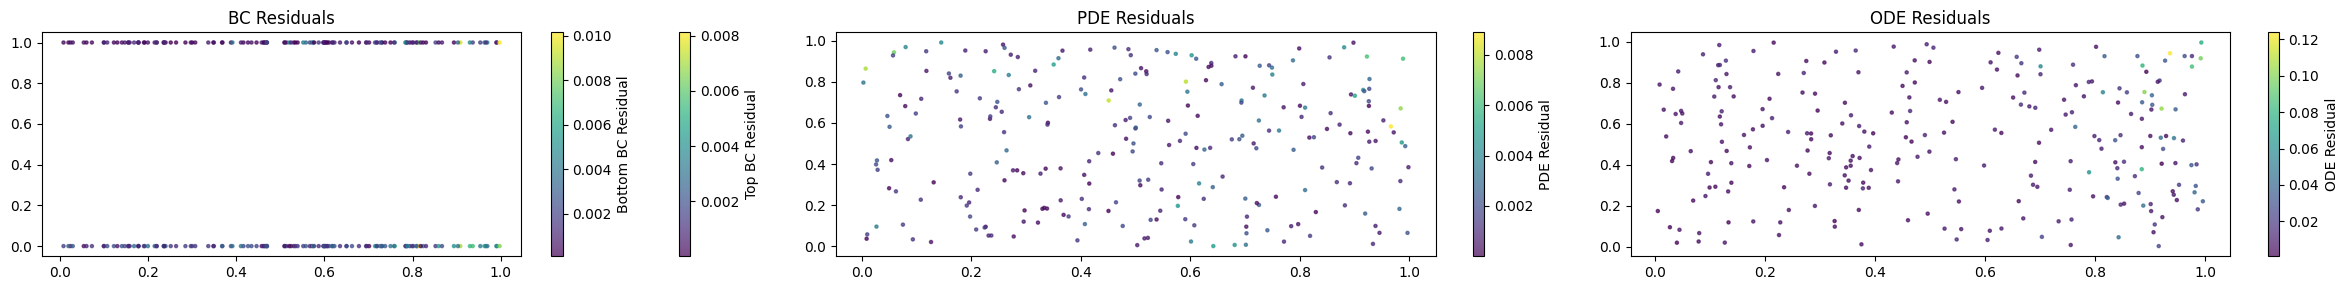

Training Progress:  29%|██████████████████████████████████████████████████▎                                                                                                                             | 40/140 [19:02<34:43, 20.84s/it, Status=** Training a **, Loss T=7.66e-05, Loss a=5.70e-05, ICs T=1.23e-06, ICs tool=2.15e-06, ICs Alpha=8.74e-07, BCs Bot=7.39e-06, BCs Top=2.44e-06, PDE Part=1.41e-05, PDE Tool=4.21e-06, Cure Part=5.62e-05, INF=4.43e-06, FLUX=1.33e-06, T lr=4.30e-04, a lr=4.30e-04]

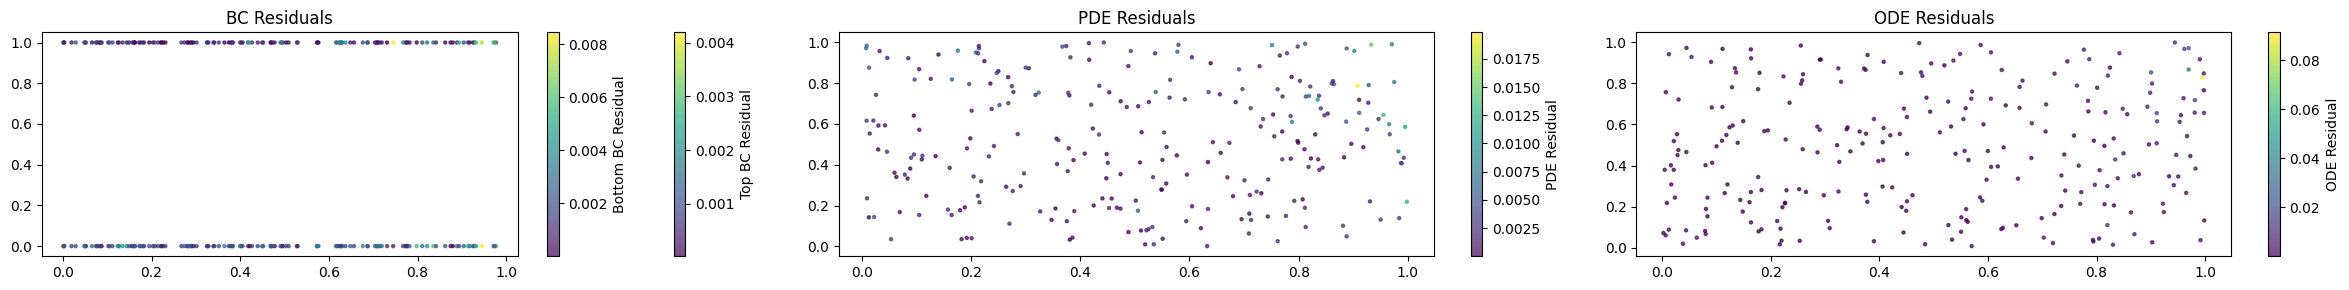

Training Progress:  36%|██████████████████████████████████████████████████████████████▊                                                                                                                 | 50/140 [25:15<54:49, 36.55s/it, Status=** Training T **, Loss T=5.39e-05, Loss a=5.51e-05, ICs T=4.12e-06, ICs tool=5.34e-07, ICs Alpha=5.26e-07, BCs Bot=2.75e-06, BCs Top=4.73e-06, PDE Part=4.82e-06, PDE Tool=3.63e-06, Cure Part=5.46e-05, INF=2.32e-06, FLUX=1.15e-06, T lr=2.82e-04, a lr=4.30e-04]

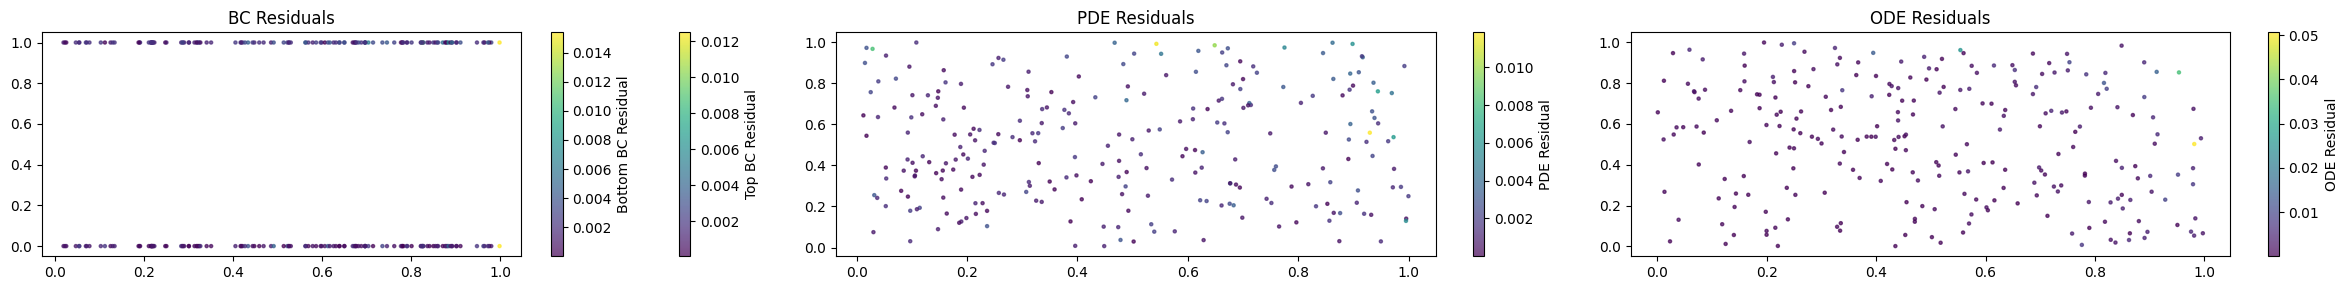

Training Progress:  43%|███████████████████████████████████████████████████████████████████████████▍                                                                                                    | 60/140 [28:43<29:42, 22.28s/it, Status=** Training a **, Loss T=2.98e-04, Loss a=1.14e-05, ICs T=4.71e-06, ICs tool=7.09e-07, ICs Alpha=3.74e-07, BCs Bot=2.81e-06, BCs Top=6.34e-06, PDE Part=2.40e-04, PDE Tool=4.72e-06, Cure Part=1.10e-05, INF=1.79e-06, FLUX=8.20e-07, T lr=2.82e-04, a lr=2.82e-04]

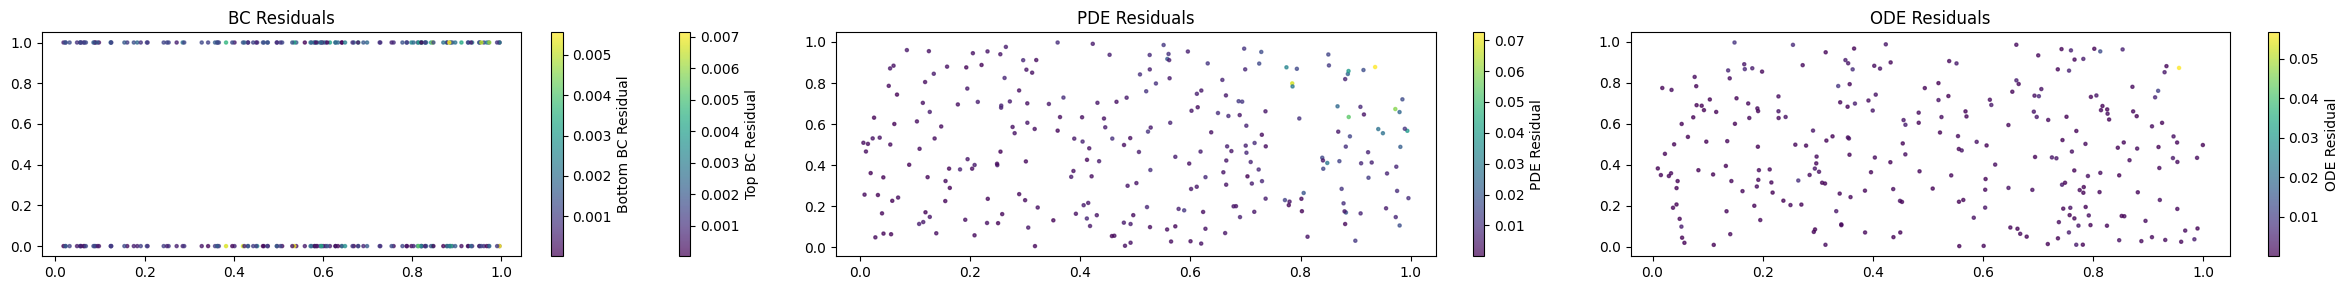

Training Progress:  50%|████████████████████████████████████████████████████████████████████████████████████████                                                                                        | 70/140 [34:45<41:52, 35.89s/it, Status=** Training T **, Loss T=2.70e-05, Loss a=1.07e-05, ICs T=2.30e-07, ICs tool=7.31e-07, ICs Alpha=2.65e-07, BCs Bot=2.37e-06, BCs Top=1.27e-06, PDE Part=3.54e-06, PDE Tool=2.34e-06, Cure Part=1.04e-05, INF=1.17e-06, FLUX=8.16e-07, T lr=1.85e-04, a lr=2.82e-04]

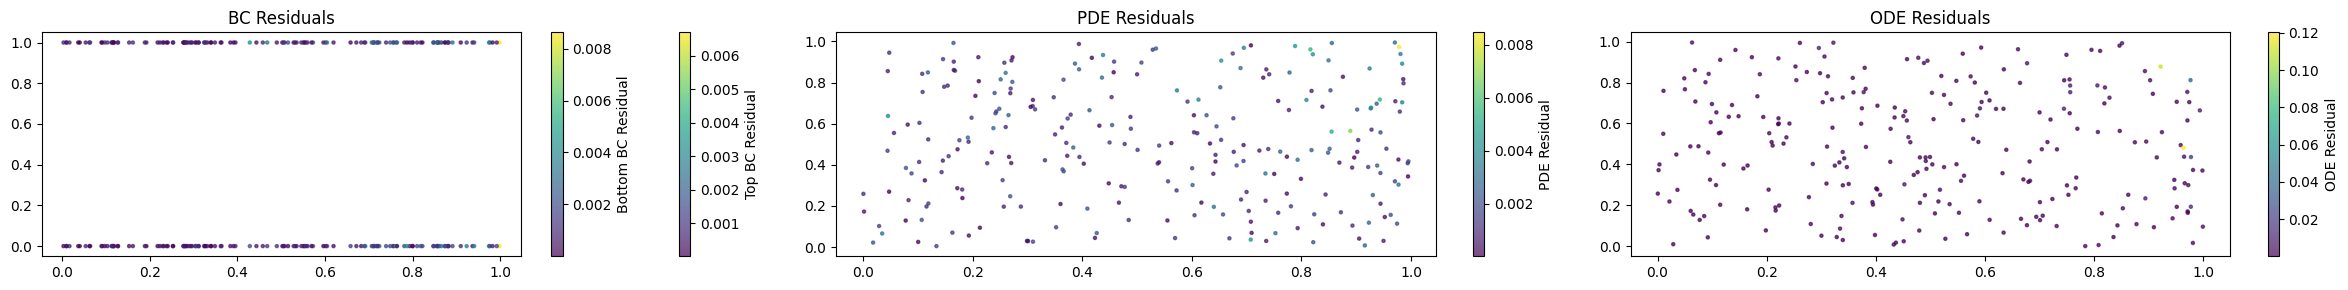

Training Progress:  57%|████████████████████████████████████████████████████████████████████████████████████████████████████▌                                                                           | 80/140 [38:06<20:44, 20.75s/it, Status=** Training a **, Loss T=2.69e-05, Loss a=8.70e-06, ICs T=5.58e-07, ICs tool=7.29e-07, ICs Alpha=5.70e-07, BCs Bot=2.36e-06, BCs Top=1.09e-06, PDE Part=4.34e-06, PDE Tool=2.33e-06, Cure Part=8.13e-06, INF=7.43e-07, FLUX=9.03e-07, T lr=1.85e-04, a lr=1.85e-04]

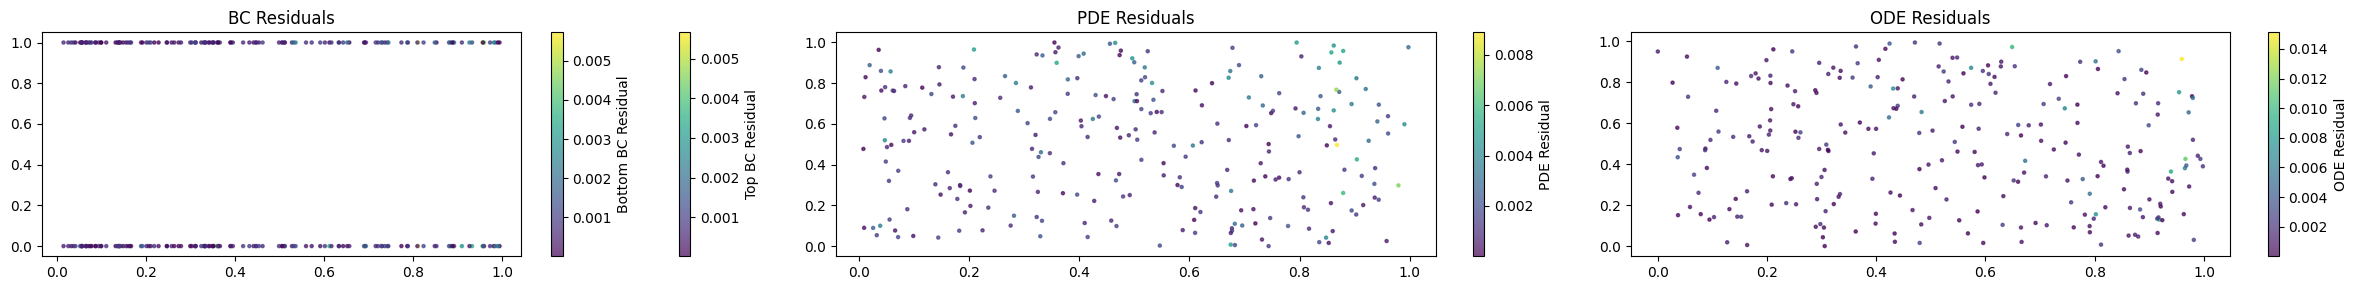

Training Progress:  64%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                                                              | 90/140 [44:17<30:18, 36.37s/it, Status=** Training T **, Loss T=2.69e-05, Loss a=3.71e-05, ICs T=1.64e-06, ICs tool=3.19e-07, ICs Alpha=2.41e-07, BCs Bot=2.04e-06, BCs Top=1.12e-06, PDE Part=4.08e-06, PDE Tool=2.57e-06, Cure Part=3.69e-05, INF=1.93e-06, FLUX=5.83e-07, T lr=1.21e-04, a lr=1.85e-04]

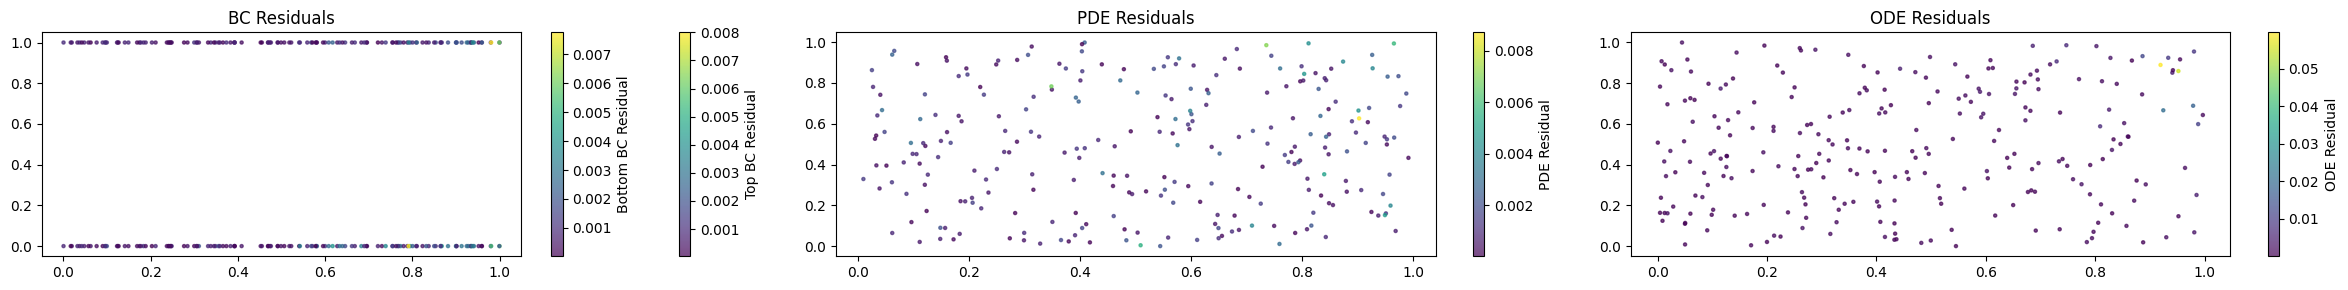

Training Progress:  71%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████                                                  | 100/140 [47:38<13:38, 20.46s/it, Status=** Training a **, Loss T=2.99e-05, Loss a=8.25e-06, ICs T=1.85e-06, ICs tool=4.43e-07, ICs Alpha=1.12e-07, BCs Bot=2.63e-06, BCs Top=1.36e-06, PDE Part=3.22e-06, PDE Tool=2.63e-06, Cure Part=8.13e-06, INF=1.36e-06, FLUX=4.75e-07, T lr=1.21e-04, a lr=1.21e-04]

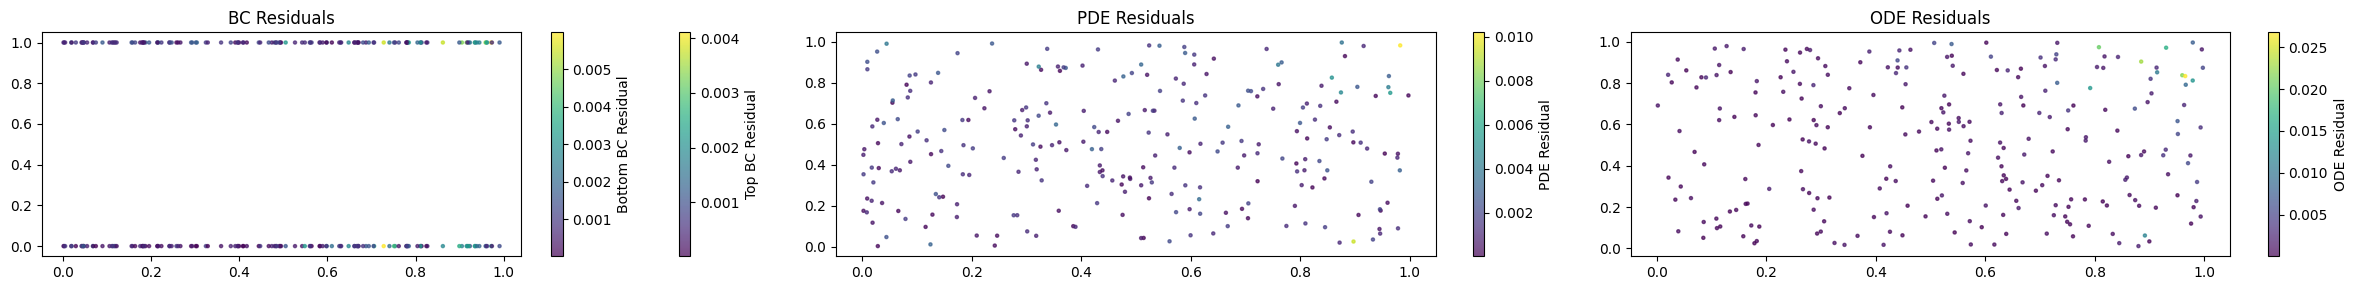

Training Progress:  79%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                                     | 110/140 [53:45<18:05, 36.19s/it, Status=** Training T **, Loss T=1.41e-05, Loss a=6.94e-06, ICs T=4.17e-07, ICs tool=2.23e-07, ICs Alpha=1.69e-07, BCs Bot=9.22e-07, BCs Top=8.18e-07, PDE Part=1.85e-06, PDE Tool=1.70e-06, Cure Part=6.77e-06, INF=6.27e-07, FLUX=6.12e-07, T lr=7.95e-05, a lr=1.21e-04]

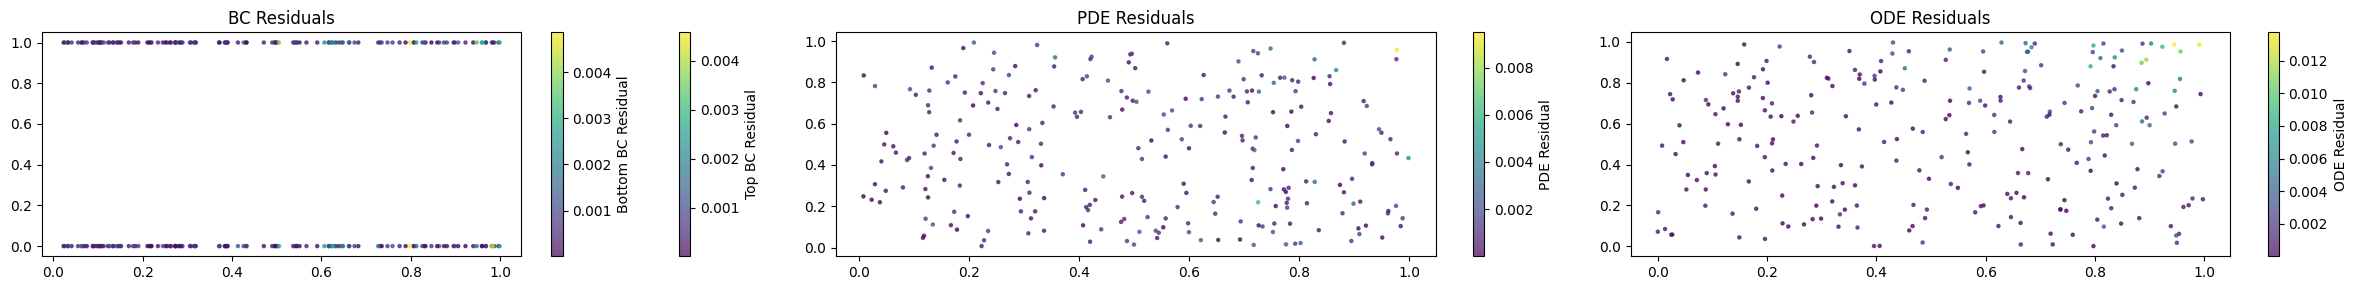

Training Progress:  86%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████                         | 120/140 [57:04<06:44, 20.24s/it, Status=** Training a **, Loss T=5.74e-04, Loss a=2.90e-06, ICs T=3.26e-07, ICs tool=2.11e-07, ICs Alpha=1.07e-07, BCs Bot=1.07e-06, BCs Top=9.37e-07, PDE Part=5.60e-04, PDE Tool=2.19e-06, Cure Part=2.80e-06, INF=7.79e-07, FLUX=5.70e-07, T lr=7.95e-05, a lr=7.95e-05]

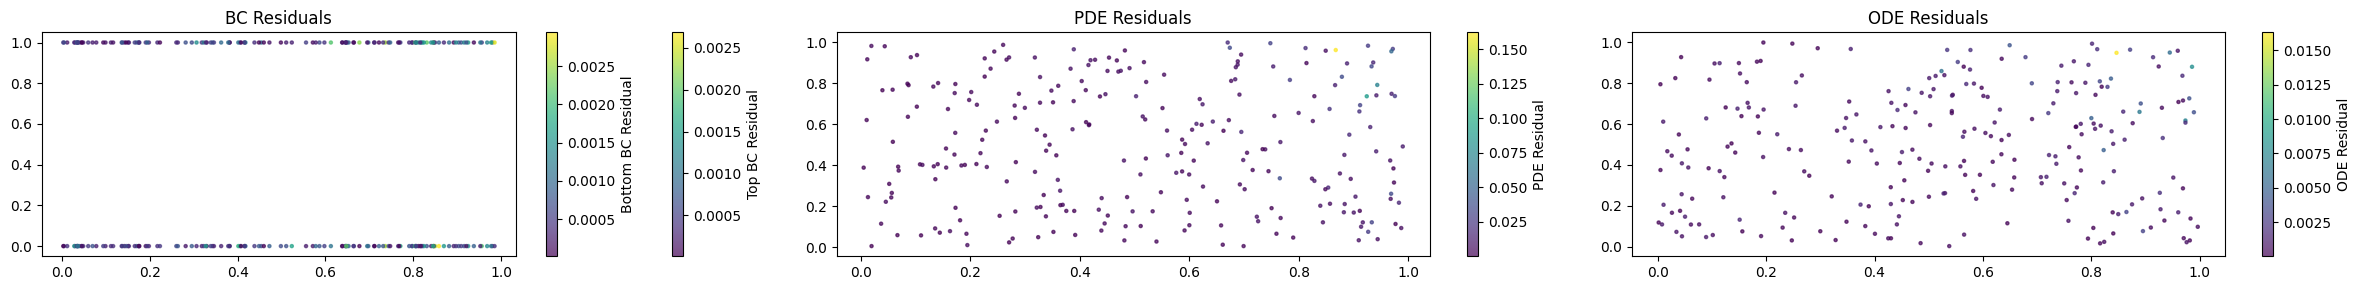

Training Progress:  93%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋            | 130/140 [1:03:09<05:57, 35.75s/it, Status=** Training T **, Loss T=1.62e-05, Loss a=8.31e-06, ICs T=1.54e-07, ICs tool=2.65e-07, ICs Alpha=8.08e-08, BCs Bot=1.03e-06, BCs Top=7.16e-07, PDE Part=3.95e-06, PDE Tool=1.89e-06, Cure Part=8.23e-06, INF=7.80e-07, FLUX=3.95e-07, T lr=5.21e-05, a lr=7.95e-05]

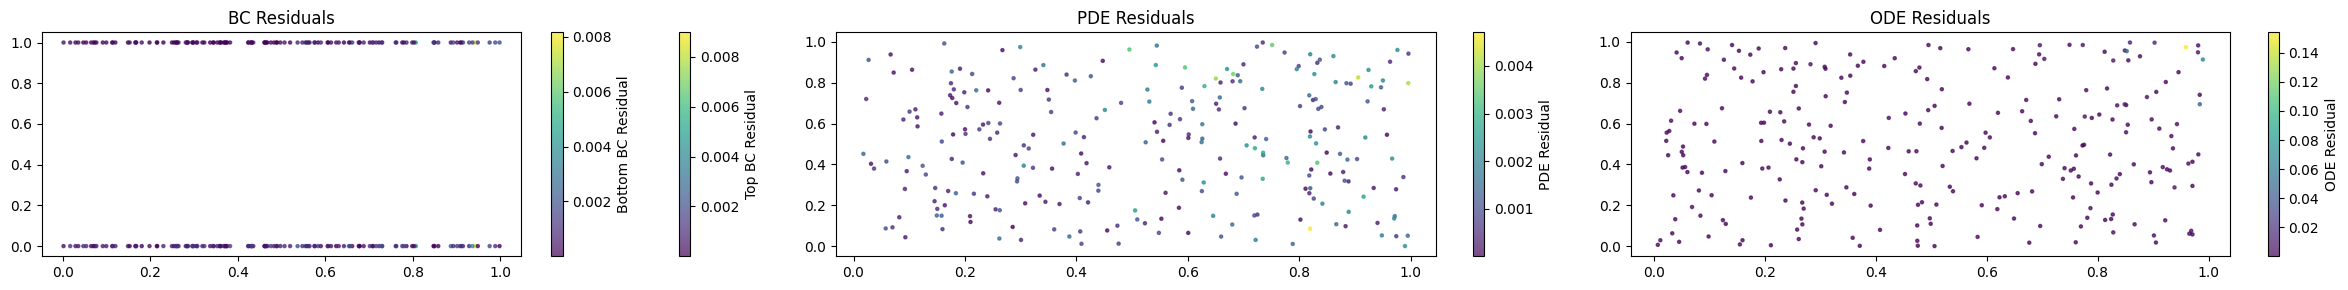

Training Progress: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 140/140 [1:06:27<00:00, 28.48s/it, Status=** Training a **, Loss T=1.76e-05, Loss a=2.61e-06, ICs T=2.74e-07, ICs tool=3.32e-07, ICs Alpha=7.78e-08, BCs Bot=9.91e-07, BCs Top=9.68e-07, PDE Part=3.00e-06, PDE Tool=2.49e-06, Cure Part=2.53e-06, INF=1.18e-06, FLUX=5.16e-07, T lr=5.21e-05, a lr=5.21e-05]



Subdomain converged: loss_T=1.76e-05, loss_a=2.61e-06

Model saved for subdomain 0.2000 - 0.4000
Status: converged

--- Processing Sub-domain: 3/5 ---
Time range: 7520.00 to 11280.00 seconds
Loaded pre-trained parameters from xpidon_class_04_T.pkl and xpidon_class_04_a.pkl
Loaded pre-trained parameters from xpidon_class_04_T.pkl and xpidon_class_04_a.pkl
Current subdomain initialized from previous subdomain weights.


Training Progress:   7%|████████████▍                                                                                                                                                                 | 10/140 [06:24<1:20:15, 37.04s/it, Status=** Training a **, Loss T=2.43e-04, Loss a=2.35e-01, ICs T=1.40e-05, ICs tool=2.67e-05, ICs Alpha=3.63e-03, BCs Bot=2.33e-05, BCs Top=9.33e-06, PDE Part=1.86e-05, PDE Tool=1.13e-05, Cure Part=2.31e-01, INF=4.18e-06, FLUX=4.56e-06, T lr=6.56e-04, a lr=1.00e-03]

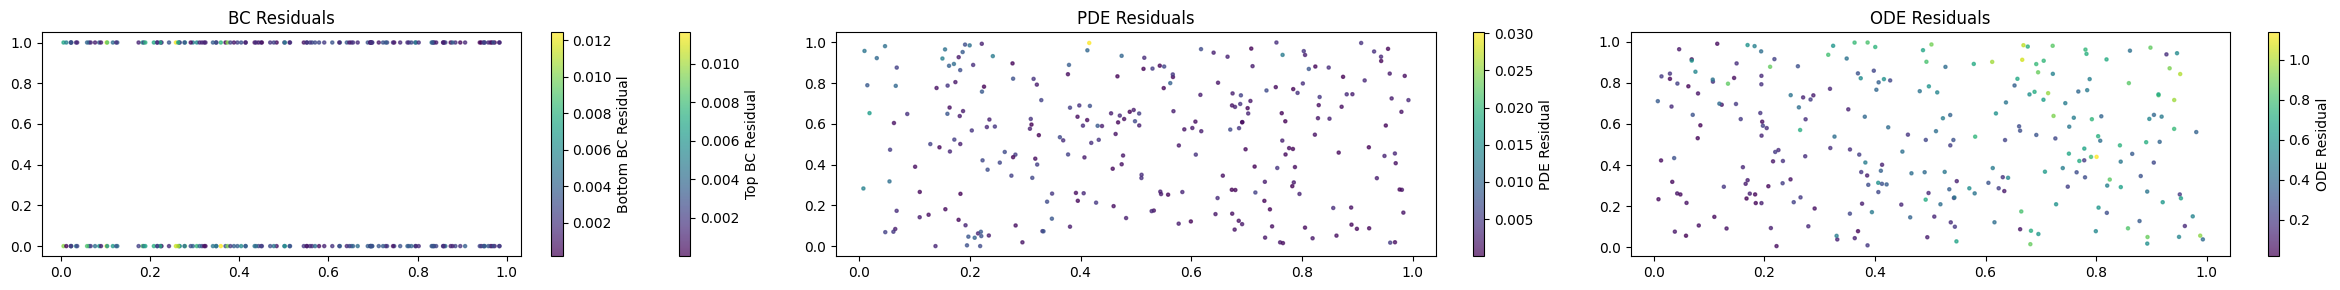

Training Progress:  14%|█████████████████████████▏                                                                                                                                                      | 20/140 [09:44<41:01, 20.51s/it, Status=** Training a **, Loss T=2.34e-04, Loss a=2.79e-05, ICs T=1.21e-05, ICs tool=2.25e-05, ICs Alpha=2.38e-06, BCs Bot=2.30e-05, BCs Top=9.40e-06, PDE Part=1.78e-05, PDE Tool=1.29e-05, Cure Part=2.55e-05, INF=3.38e-06, FLUX=3.88e-06, T lr=6.56e-04, a lr=6.56e-04]

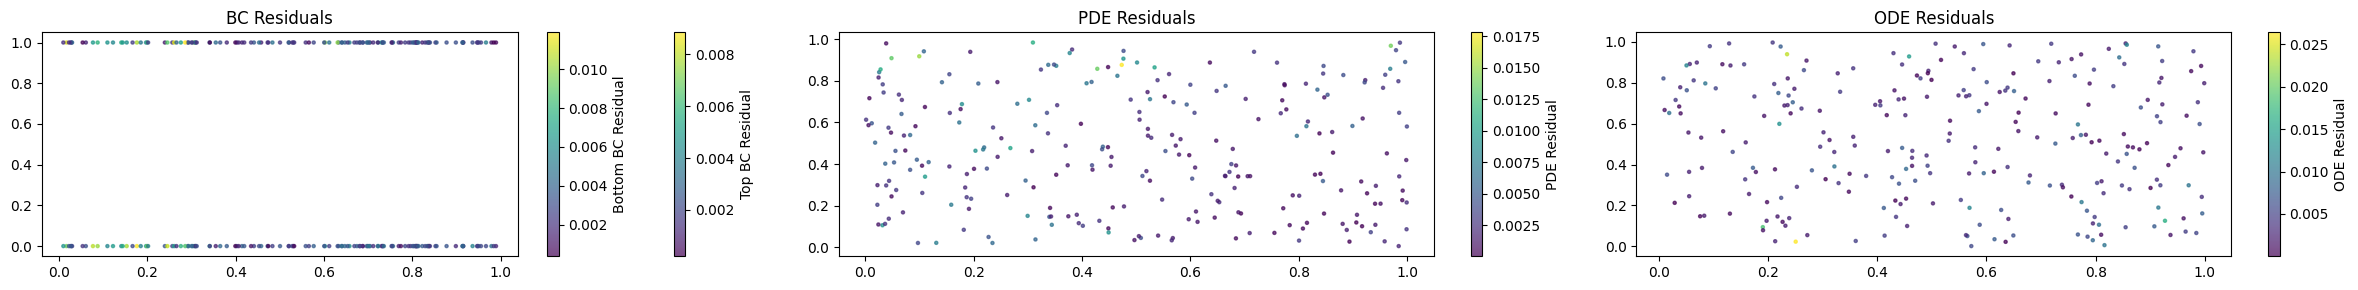

Training Progress:  21%|█████████████████████████████████████▎                                                                                                                                        | 30/140 [15:53<1:06:12, 36.11s/it, Status=** Training T **, Loss T=9.77e-05, Loss a=7.13e-03, ICs T=8.04e-06, ICs tool=2.62e-06, ICs Alpha=3.11e-06, BCs Bot=7.44e-06, BCs Top=4.62e-06, PDE Part=1.07e-05, PDE Tool=4.78e-06, Cure Part=7.13e-03, INF=1.02e-05, FLUX=1.20e-06, T lr=4.30e-04, a lr=6.56e-04]

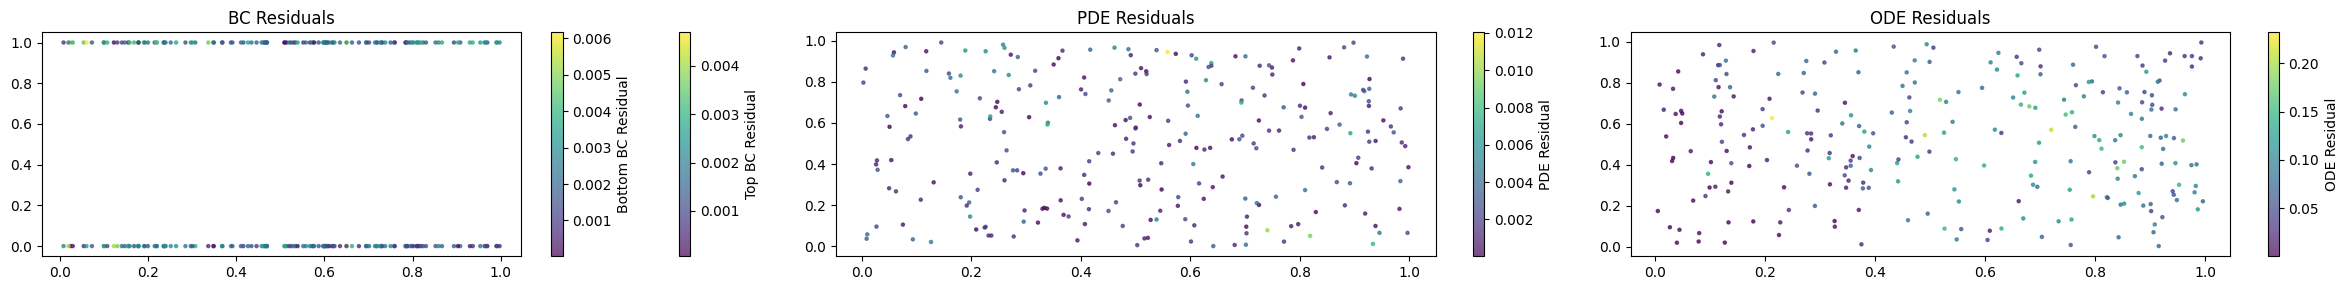

Training Progress:  29%|██████████████████████████████████████████████████▎                                                                                                                             | 40/140 [19:11<33:34, 20.14s/it, Status=** Training a **, Loss T=2.24e-04, Loss a=2.03e-05, ICs T=8.50e-06, ICs tool=2.29e-06, ICs Alpha=3.48e-06, BCs Bot=7.69e-06, BCs Top=6.67e-06, PDE Part=1.25e-04, PDE Tool=4.33e-06, Cure Part=1.69e-05, INF=1.03e-05, FLUX=1.63e-06, T lr=4.30e-04, a lr=4.30e-04]

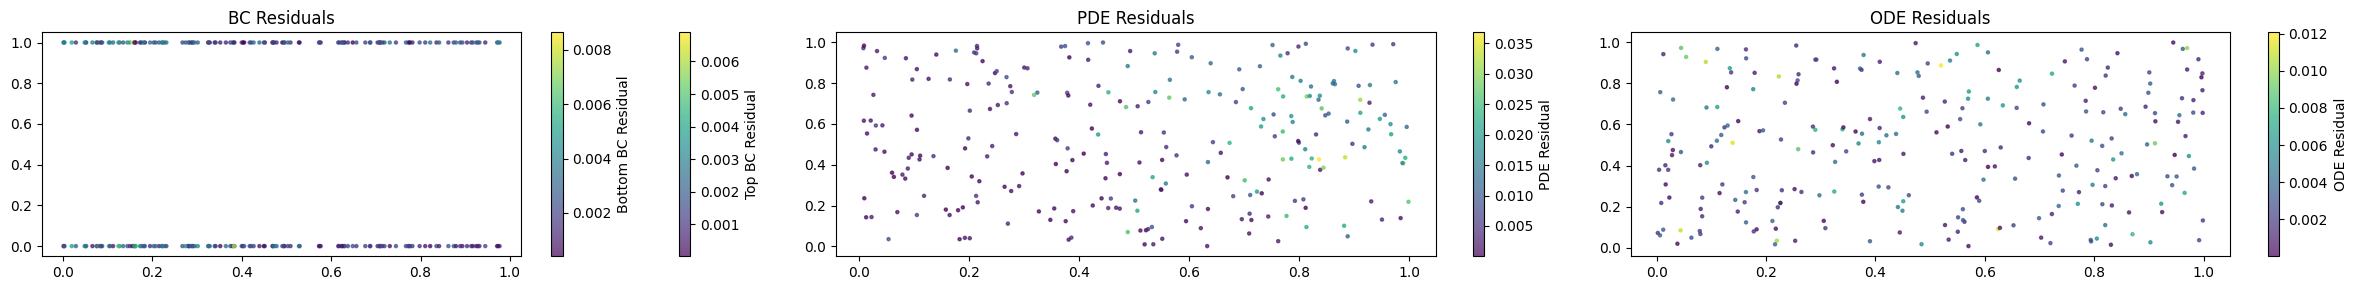

Training Progress:  36%|██████████████████████████████████████████████████████████████▊                                                                                                                 | 50/140 [25:15<53:59, 35.99s/it, Status=** Training T **, Loss T=2.18e-05, Loss a=2.24e-04, ICs T=8.41e-07, ICs tool=9.24e-07, ICs Alpha=2.21e-06, BCs Bot=1.51e-06, BCs Top=6.14e-07, PDE Part=4.18e-06, PDE Tool=2.58e-06, Cure Part=2.22e-04, INF=1.55e-06, FLUX=1.09e-06, T lr=2.82e-04, a lr=4.30e-04]

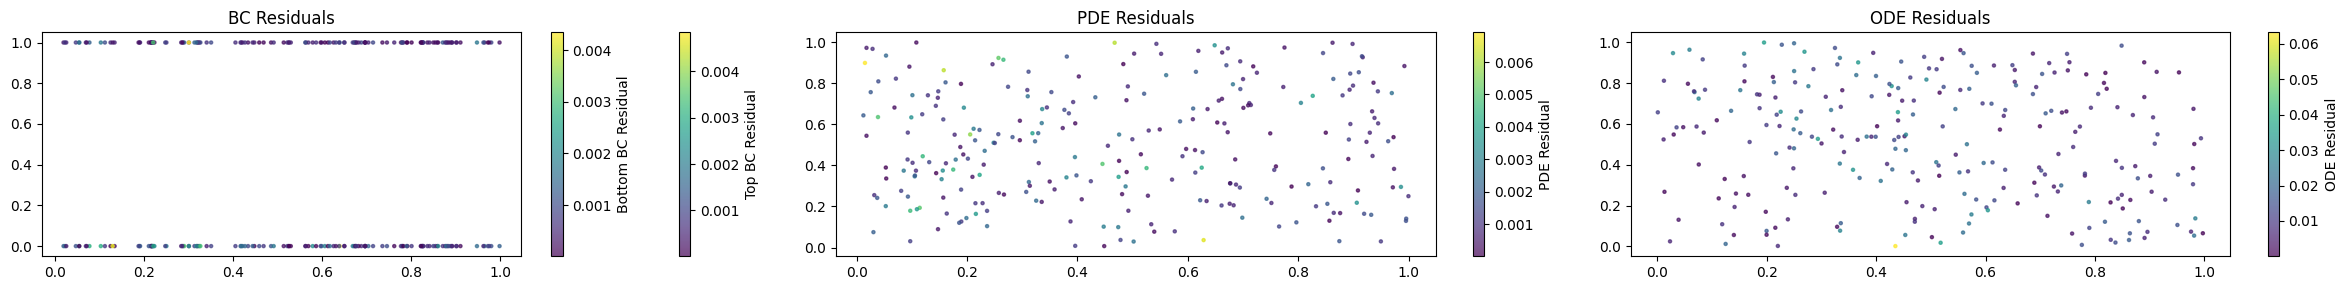

Training Progress:  43%|███████████████████████████████████████████████████████████████████████████▍                                                                                                    | 60/140 [28:32<26:37, 19.96s/it, Status=** Training a **, Loss T=9.44e-03, Loss a=1.32e-05, ICs T=9.37e-07, ICs tool=9.64e-07, ICs Alpha=1.85e-06, BCs Bot=1.89e-06, BCs Top=7.57e-07, PDE Part=9.42e-03, PDE Tool=3.17e-06, Cure Part=1.14e-05, INF=1.50e-06, FLUX=2.18e-06, T lr=2.82e-04, a lr=2.82e-04]

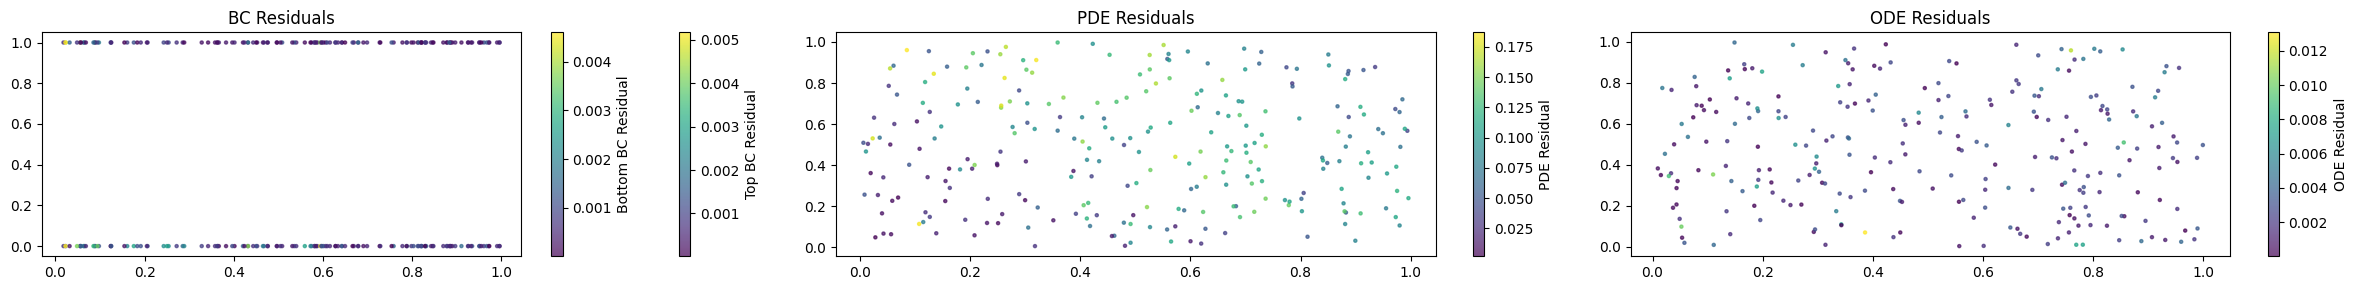

Training Progress:  50%|████████████████████████████████████████████████████████████████████████████████████████                                                                                        | 70/140 [34:31<41:28, 35.55s/it, Status=** Training T **, Loss T=3.53e-05, Loss a=9.99e-03, ICs T=2.55e-06, ICs tool=6.06e-07, ICs Alpha=3.61e-06, BCs Bot=2.09e-06, BCs Top=9.56e-07, PDE Part=1.07e-05, PDE Tool=3.61e-06, Cure Part=9.98e-03, INF=1.98e-06, FLUX=6.70e-07, T lr=1.85e-04, a lr=2.82e-04]

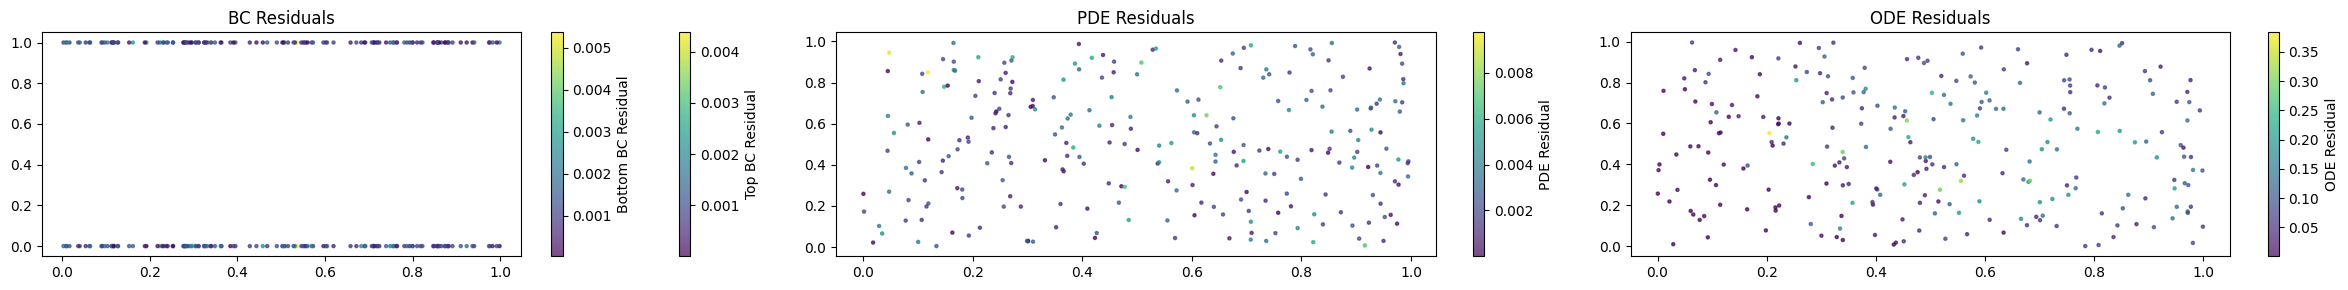

Training Progress:  57%|████████████████████████████████████████████████████████████████████████████████████████████████████▌                                                                           | 80/140 [37:48<19:51, 19.86s/it, Status=** Training a **, Loss T=6.95e-04, Loss a=1.52e-05, ICs T=2.14e-06, ICs tool=7.10e-07, ICs Alpha=9.50e-07, BCs Bot=2.31e-06, BCs Top=9.61e-07, PDE Part=6.70e-04, PDE Tool=3.66e-06, Cure Part=1.42e-05, INF=1.41e-06, FLUX=6.08e-07, T lr=1.85e-04, a lr=1.85e-04]

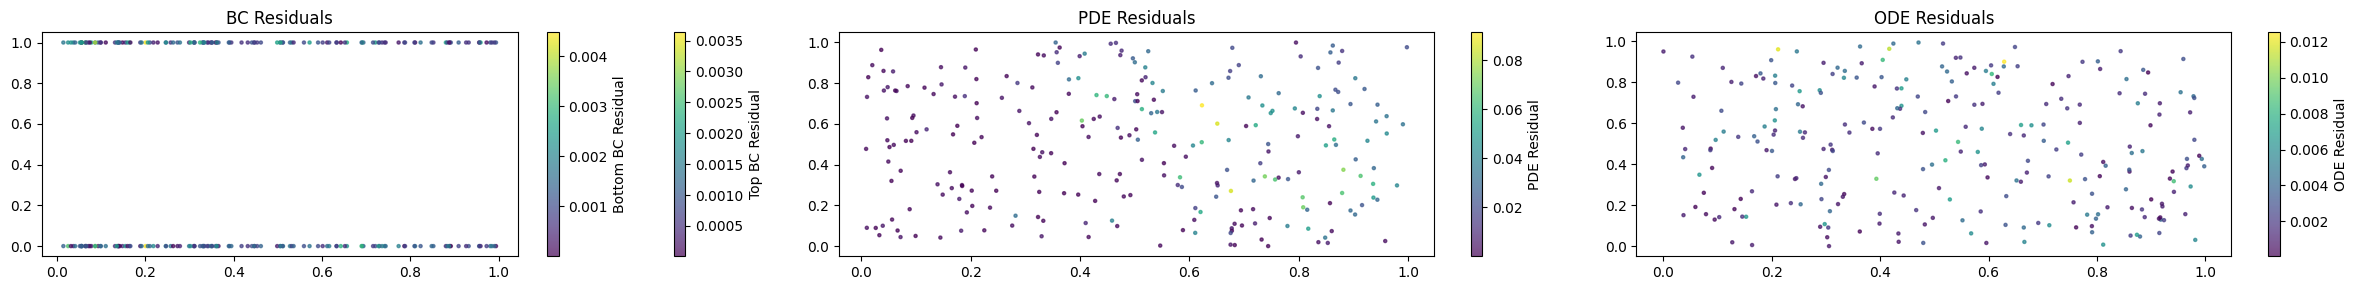

Training Progress:  64%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                                                              | 90/140 [43:45<29:19, 35.19s/it, Status=** Training T **, Loss T=2.82e-05, Loss a=2.43e-02, ICs T=8.38e-07, ICs tool=5.91e-07, ICs Alpha=9.14e-07, BCs Bot=7.75e-07, BCs Top=8.00e-07, PDE Part=1.17e-05, PDE Tool=2.36e-06, Cure Part=2.43e-02, INF=3.29e-06, FLUX=1.50e-06, T lr=1.21e-04, a lr=1.85e-04]

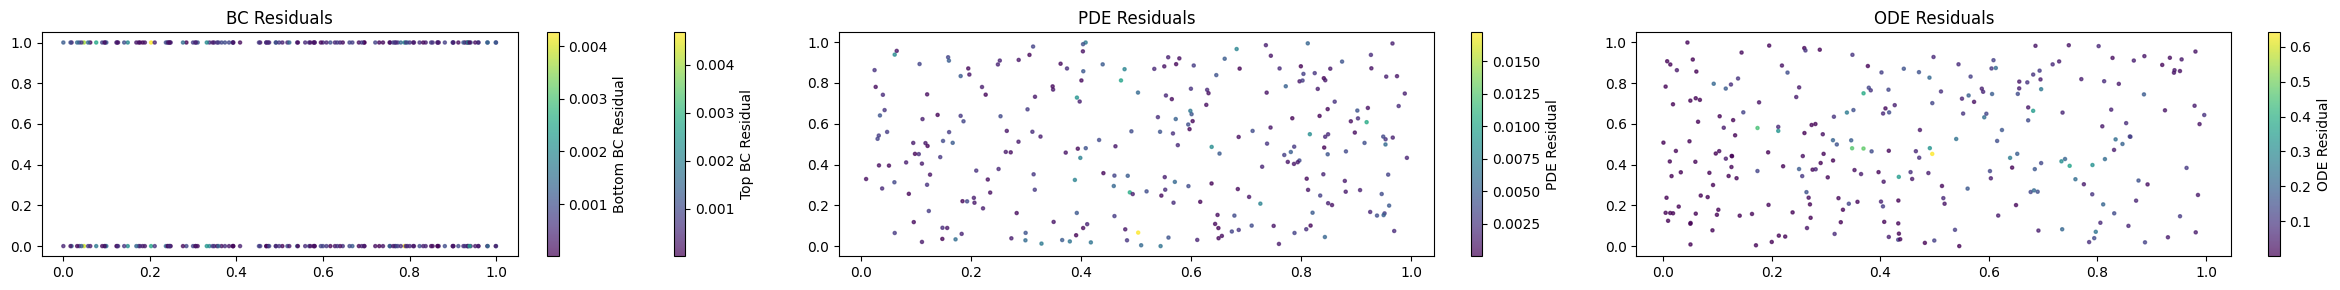

Training Progress:  71%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████                                                  | 100/140 [47:01<13:17, 19.95s/it, Status=** Training a **, Loss T=2.42e-03, Loss a=2.18e-05, ICs T=1.22e-06, ICs tool=3.35e-07, ICs Alpha=9.78e-07, BCs Bot=4.78e-07, BCs Top=8.31e-07, PDE Part=2.41e-03, PDE Tool=2.48e-06, Cure Part=2.08e-05, INF=2.76e-06, FLUX=1.39e-06, T lr=1.21e-04, a lr=1.21e-04]

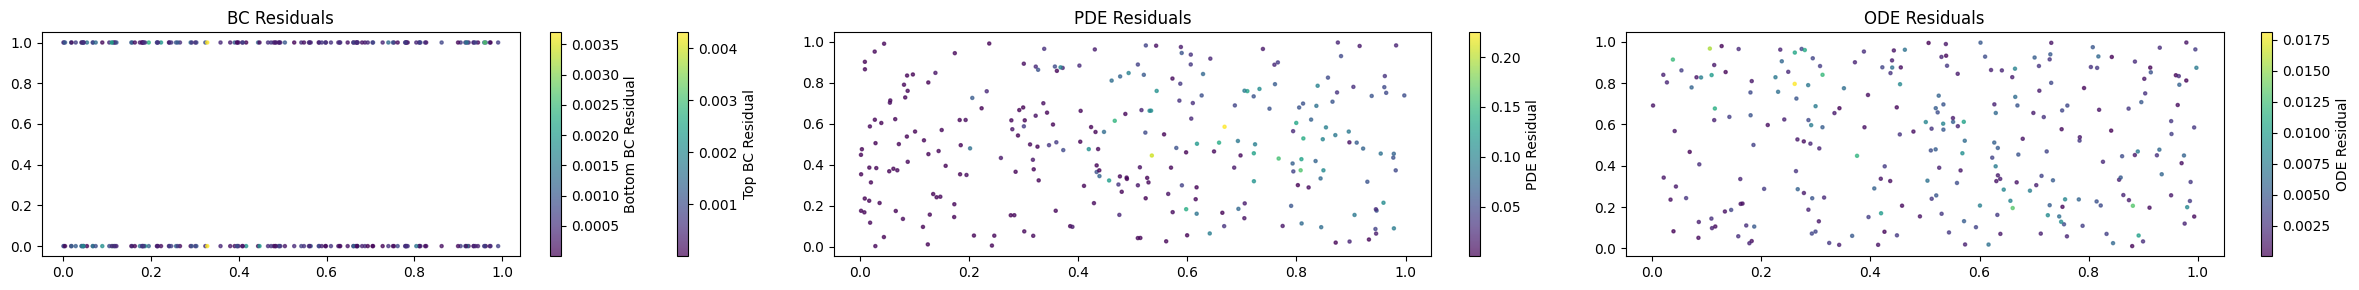

Training Progress:  79%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                                     | 110/140 [52:57<17:27, 34.91s/it, Status=** Training T **, Loss T=2.44e-05, Loss a=1.19e-03, ICs T=1.78e-06, ICs tool=3.49e-07, ICs Alpha=8.13e-07, BCs Bot=1.04e-06, BCs Top=8.35e-07, PDE Part=8.04e-06, PDE Tool=2.01e-06, Cure Part=1.19e-03, INF=1.61e-06, FLUX=1.24e-06, T lr=7.95e-05, a lr=1.21e-04]

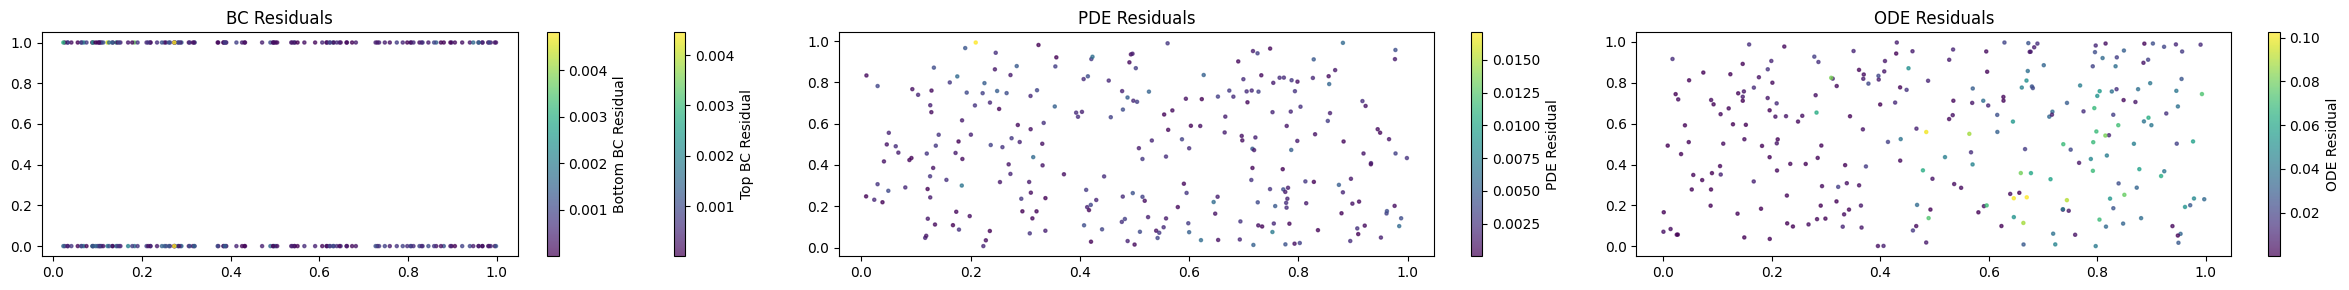

Training Progress:  86%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████                         | 120/140 [56:12<06:41, 20.08s/it, Status=** Training a **, Loss T=1.22e-02, Loss a=1.44e-05, ICs T=3.05e-06, ICs tool=3.12e-07, ICs Alpha=6.23e-07, BCs Bot=8.44e-07, BCs Top=8.26e-07, PDE Part=1.22e-02, PDE Tool=2.29e-06, Cure Part=1.38e-05, INF=2.14e-06, FLUX=1.59e-06, T lr=7.95e-05, a lr=7.95e-05]

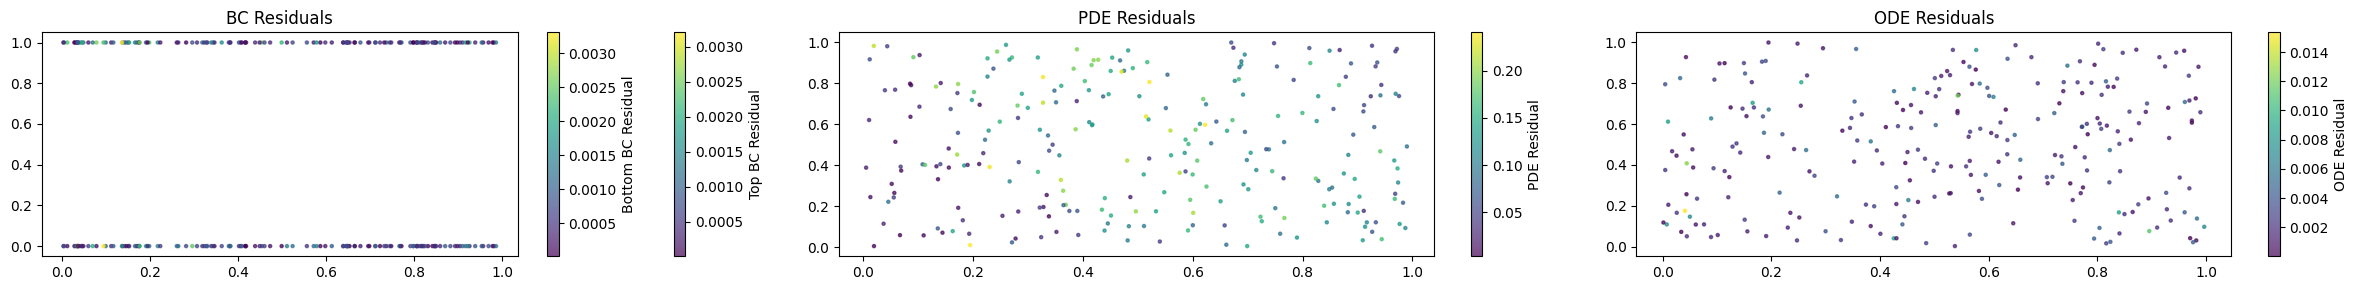

Training Progress:  93%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋            | 130/140 [1:02:09<05:51, 35.16s/it, Status=** Training T **, Loss T=6.20e-05, Loss a=5.90e-02, ICs T=6.33e-06, ICs tool=1.29e-06, ICs Alpha=1.18e-06, BCs Bot=1.01e-06, BCs Top=1.24e-06, PDE Part=2.48e-05, PDE Tool=3.33e-06, Cure Part=5.90e-02, INF=1.22e-05, FLUX=2.85e-06, T lr=5.21e-05, a lr=7.95e-05]

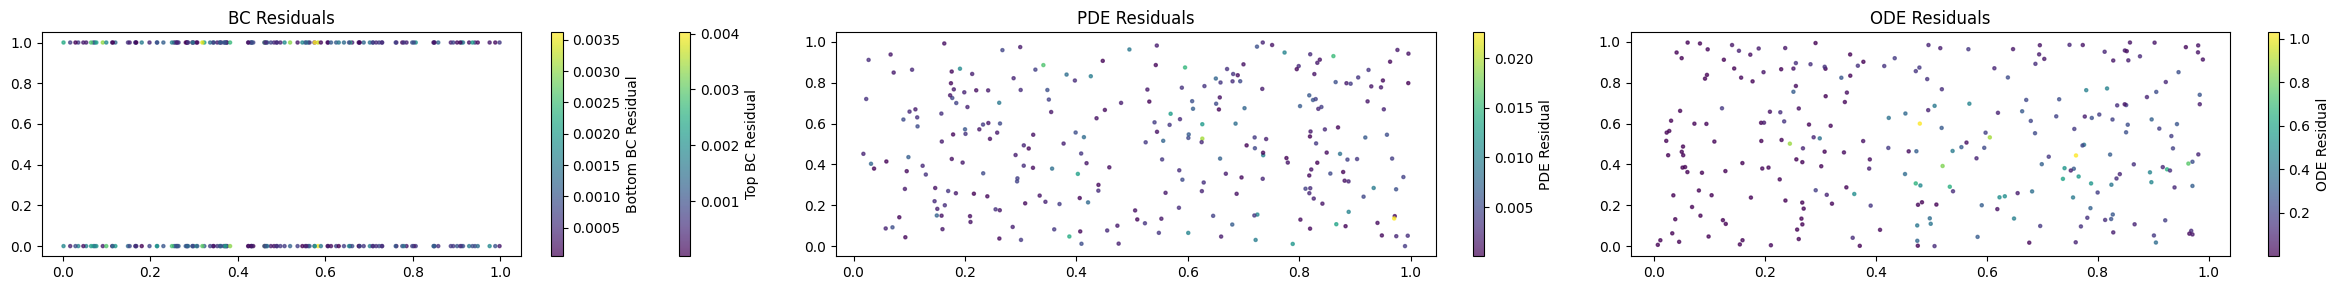

Training Progress: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 140/140 [1:05:25<00:00, 28.04s/it, Status=** Training a **, Loss T=2.11e-02, Loss a=3.78e-05, ICs T=1.47e-06, ICs tool=8.97e-07, ICs Alpha=1.94e-06, BCs Bot=1.25e-06, BCs Top=1.33e-06, PDE Part=2.10e-02, PDE Tool=3.01e-06, Cure Part=3.59e-05, INF=1.43e-05, FLUX=3.24e-06, T lr=5.21e-05, a lr=5.21e-05]



Losses exceed tolerance 5.00e-03: loss_T=2.11e-02, loss_a=3.78e-05
Splitting current interval. Current width=0.2000, new child width=0.1000
New decomposition: [0.0, 0.2, 0.4, 0.5, 0.6000000000000001, 0.8, 1.0]

--- Processing Sub-domain: 3/6 ---
Time range: 7520.00 to 9400.00 seconds
Loaded pre-trained parameters from xpidon_class_04_T.pkl and xpidon_class_04_a.pkl
Loaded pre-trained parameters from xpidon_class_04_T.pkl and xpidon_class_04_a.pkl
Current subdomain initialized from previous subdomain weights.


Training Progress:   7%|████████████▍                                                                                                                                                                 | 10/140 [06:13<1:18:50, 36.39s/it, Status=** Training a **, Loss T=2.44e-04, Loss a=2.80e-02, ICs T=1.12e-05, ICs tool=2.87e-06, ICs Alpha=3.63e-03, BCs Bot=2.54e-05, BCs Top=1.47e-05, PDE Part=9.25e-06, PDE Tool=8.10e-06, Cure Part=2.44e-02, INF=3.91e-06, FLUX=8.45e-06, T lr=6.56e-04, a lr=1.00e-03]

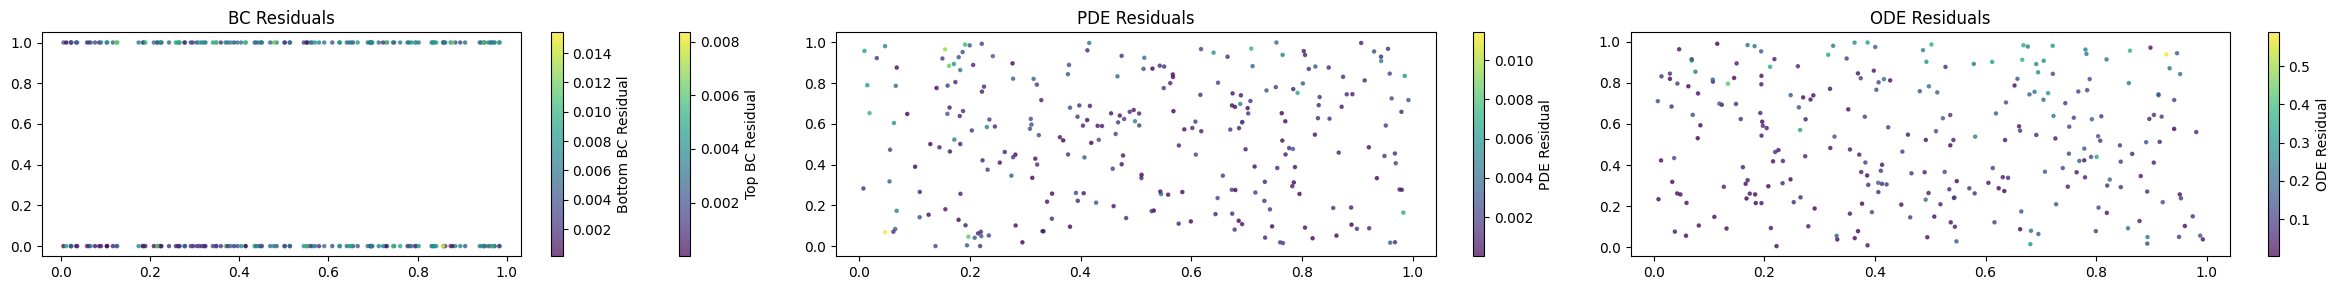

Training Progress:  14%|█████████████████████████▏                                                                                                                                                      | 20/140 [09:32<40:23, 20.20s/it, Status=** Training a **, Loss T=2.43e-04, Loss a=8.64e-06, ICs T=7.63e-06, ICs tool=3.00e-06, ICs Alpha=2.61e-06, BCs Bot=2.60e-05, BCs Top=1.51e-05, PDE Part=6.99e-06, PDE Tool=9.49e-06, Cure Part=6.03e-06, INF=4.27e-06, FLUX=6.21e-06, T lr=6.56e-04, a lr=6.56e-04]

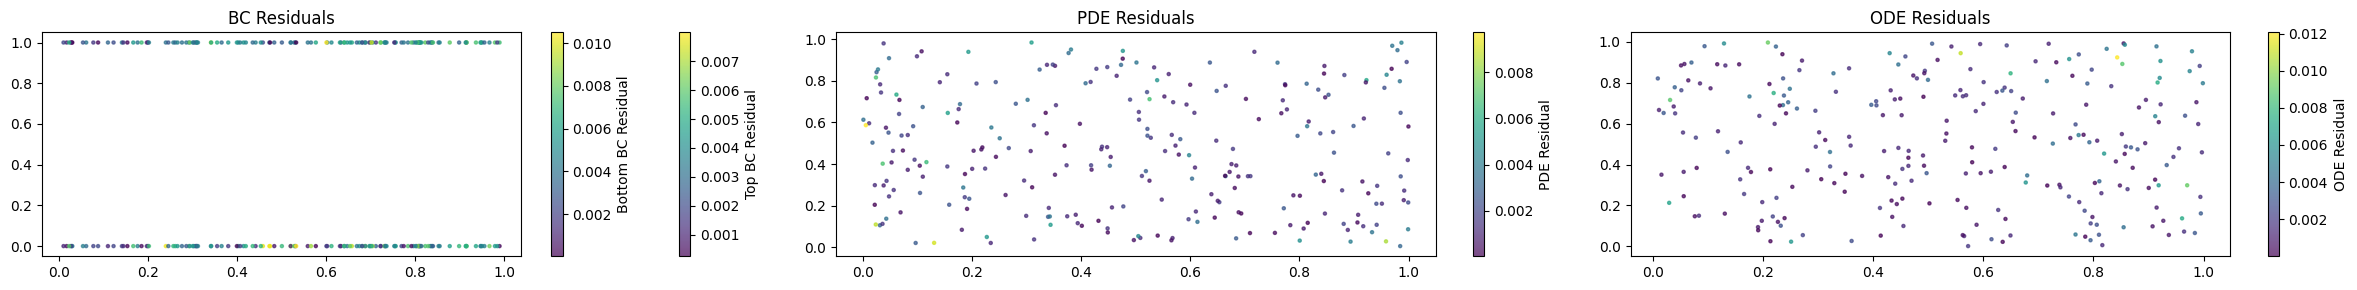

Training Progress:  21%|█████████████████████████████████████▎                                                                                                                                        | 30/140 [15:37<1:05:47, 35.89s/it, Status=** Training T **, Loss T=4.11e-05, Loss a=1.51e-03, ICs T=3.47e-06, ICs tool=1.10e-06, ICs Alpha=3.35e-06, BCs Bot=2.49e-06, BCs Top=2.40e-06, PDE Part=4.45e-06, PDE Tool=4.12e-06, Cure Part=1.50e-03, INF=2.48e-06, FLUX=1.04e-06, T lr=4.30e-04, a lr=6.56e-04]

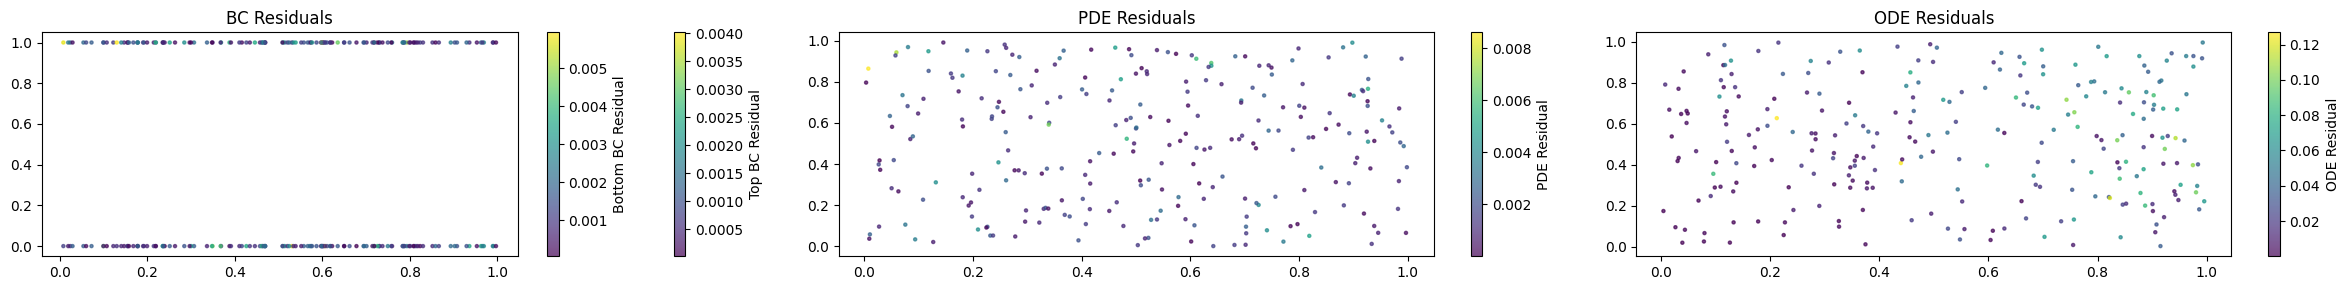

Training Progress:  29%|██████████████████████████████████████████████████▎                                                                                                                             | 40/140 [18:56<33:56, 20.36s/it, Status=** Training a **, Loss T=4.82e-05, Loss a=1.23e-05, ICs T=1.90e-06, ICs tool=1.29e-06, ICs Alpha=7.58e-07, BCs Bot=2.71e-06, BCs Top=2.14e-06, PDE Part=1.29e-05, PDE Tool=3.40e-06, Cure Part=1.15e-05, INF=2.53e-06, FLUX=1.87e-06, T lr=4.30e-04, a lr=4.30e-04]

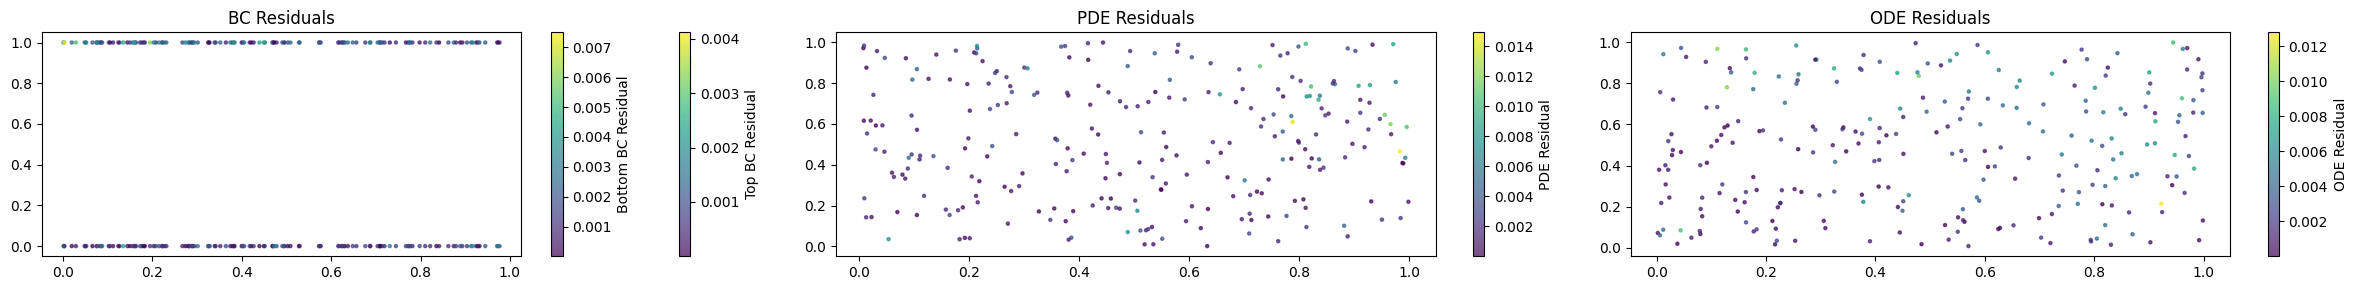

Training Progress:  34%|███████████████████████████████████████████████████████████                                                                                                                     | 47/140 [23:34<54:25, 35.11s/it, Status=** Training T **, Loss T=5.26e-05, Loss a=1.64e-05, ICs T=3.88e-06, ICs tool=4.31e-06, ICs Alpha=9.43e-07, BCs Bot=2.35e-06, BCs Top=3.13e-06, PDE Part=4.30e-06, PDE Tool=3.20e-06, Cure Part=1.54e-05, INF=6.43e-06, FLUX=3.07e-06, T lr=3.12e-04, a lr=4.30e-04]

In [ ]:
train(XPIDON, XPIDONLoss, generate_training_data, DataGenerator, Temp_air,params,exp_params,train_params,init_sub_domain,Tolerance_level,m_inp,
          branch_layers ,trunk_layers, nomad_layers_T)

In [1]:
%run plot_training_results.py

Using loss files:
  outputs/loss_data/loss_history_02000.pkl
  outputs/loss_data/loss_history_04000.pkl

Merged loss length:
loss_T 1260
loss_a 1260
loss_ics_T 1260
loss_ics_tool 1260
loss_ics_a 1260
loss_bct 1260
loss_bcb 1260
loss_res 1260
loss_res_tool 1260
loss_ode 1260
loss_inf 1260
loss_flux 1260
convergence_status 18
Saved: outputs/loss_data/loss_history_merged.pkl
Saved: outputs/figures/temperature_network_loss.png


Platform 'METAL' is experimental and not all JAX functionality may be correctly supported!


Saved: outputs/figures/doc_network_loss.png

Using model tags:
02000 outputs/models/xpidon_class_02000_T.pkl outputs/models/xpidon_class_02000_a.pkl
04000 outputs/models/xpidon_class_04000_T.pkl outputs/models/xpidon_class_04000_a.pkl

Validation case in physical units:
ramp1 = 2.2 C/min
hold1 = 110.0 C, 58.0 min
ramp2 = 2.2 C/min
hold2 = 180.0 C, 105.0 min
hbot   = 90.0 W/m2K
htop   = 75.0 W/m2K
Lt     = 0.025 m

Scaled XPIDON input:
[2.7573333  0.44       0.18510638 2.7573333  0.72       0.33510637
 0.75       0.625      0.5       ]
Metal device set to: Apple M4 Pro

systemMemory: 24.00 GB
maxCacheSize: 8.00 GB



W0000 00:00:1783993813.909650 1403760 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1783993813.922704 1403760 service.cc:145] XLA service 0x10ff6ba60 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1783993813.922729 1403760 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1783993813.923942 1403760 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1783993813.923953 1403760 mps_client.cc:384] XLA backend will use up to 17179410432 bytes on device 0 for SimpleAllocator.



Exotherm diagnostic:
Maximum T_part - T_air = 0.128265380859375 C
Peak time = 0.0 min
Part temperature at peak = 20.128263473510742 C
Air temperature at peak = 19.999998092651367 C
Saved: outputs/predictions/final_temperature_doc_prediction.pkl
Saved: outputs/predictions/final_temperature_doc_prediction.csv
Saved: outputs/figures/final_temperature_doc_prediction.png

Done. All generated files are inside outputs/.


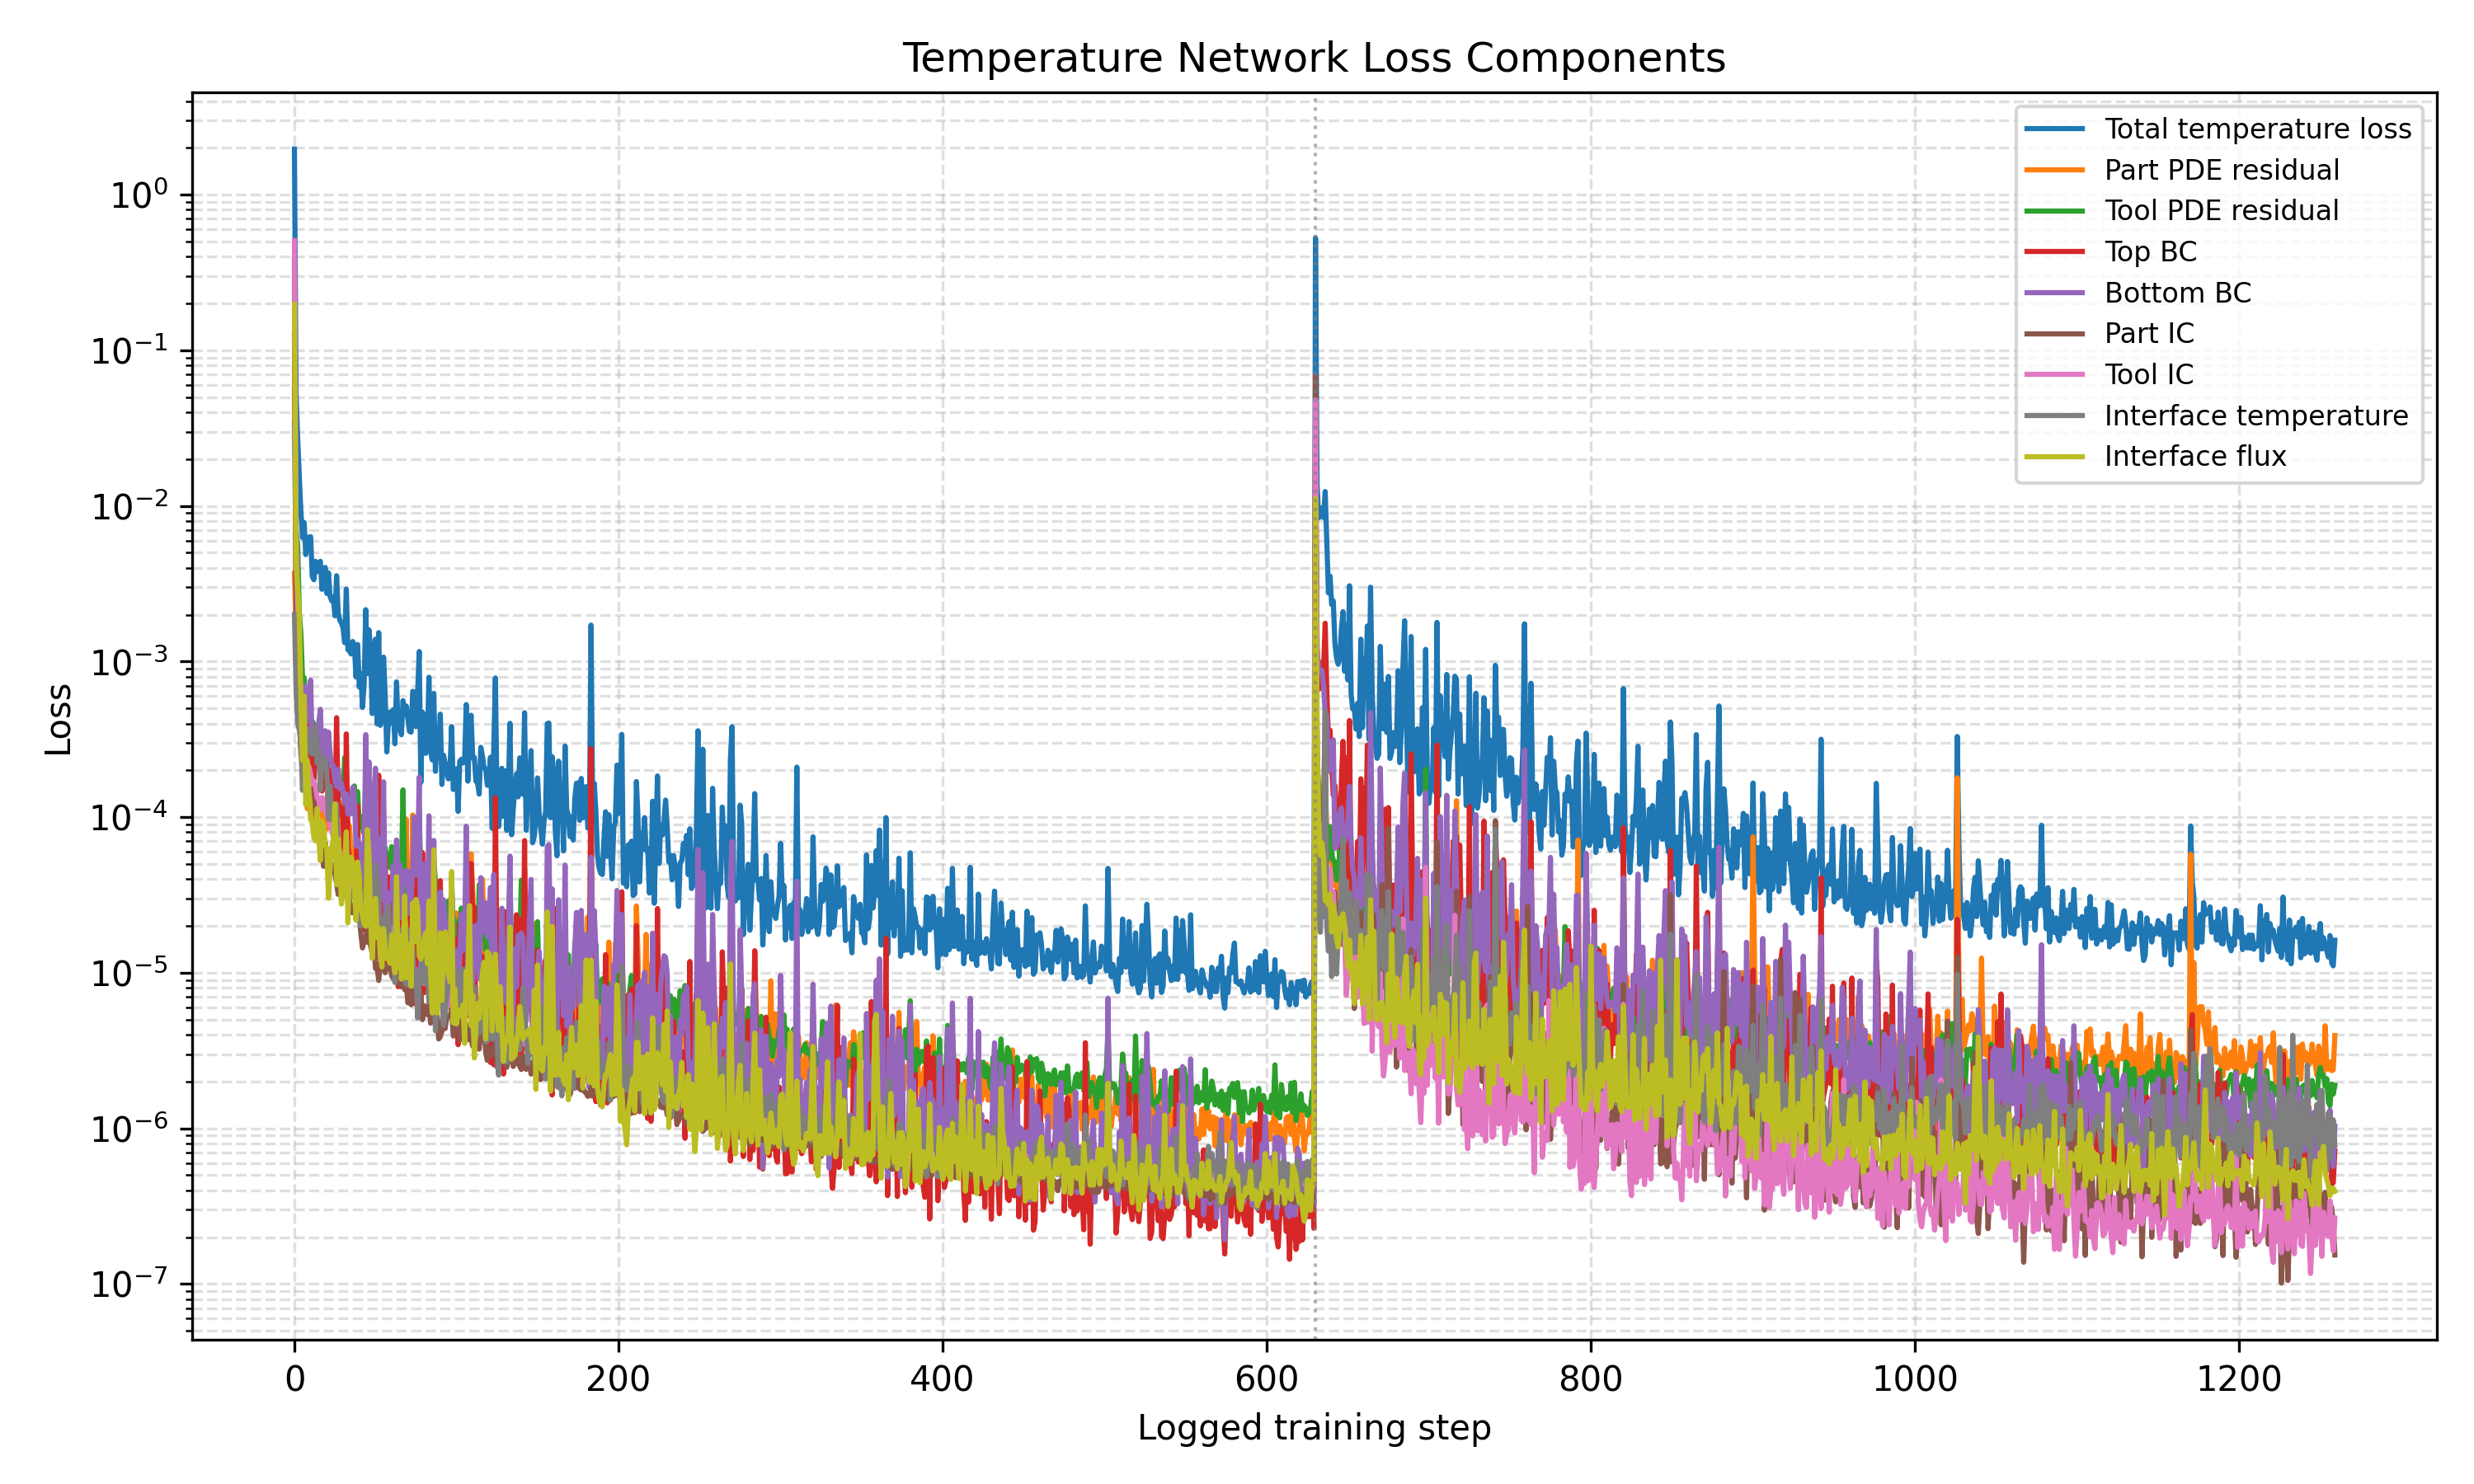

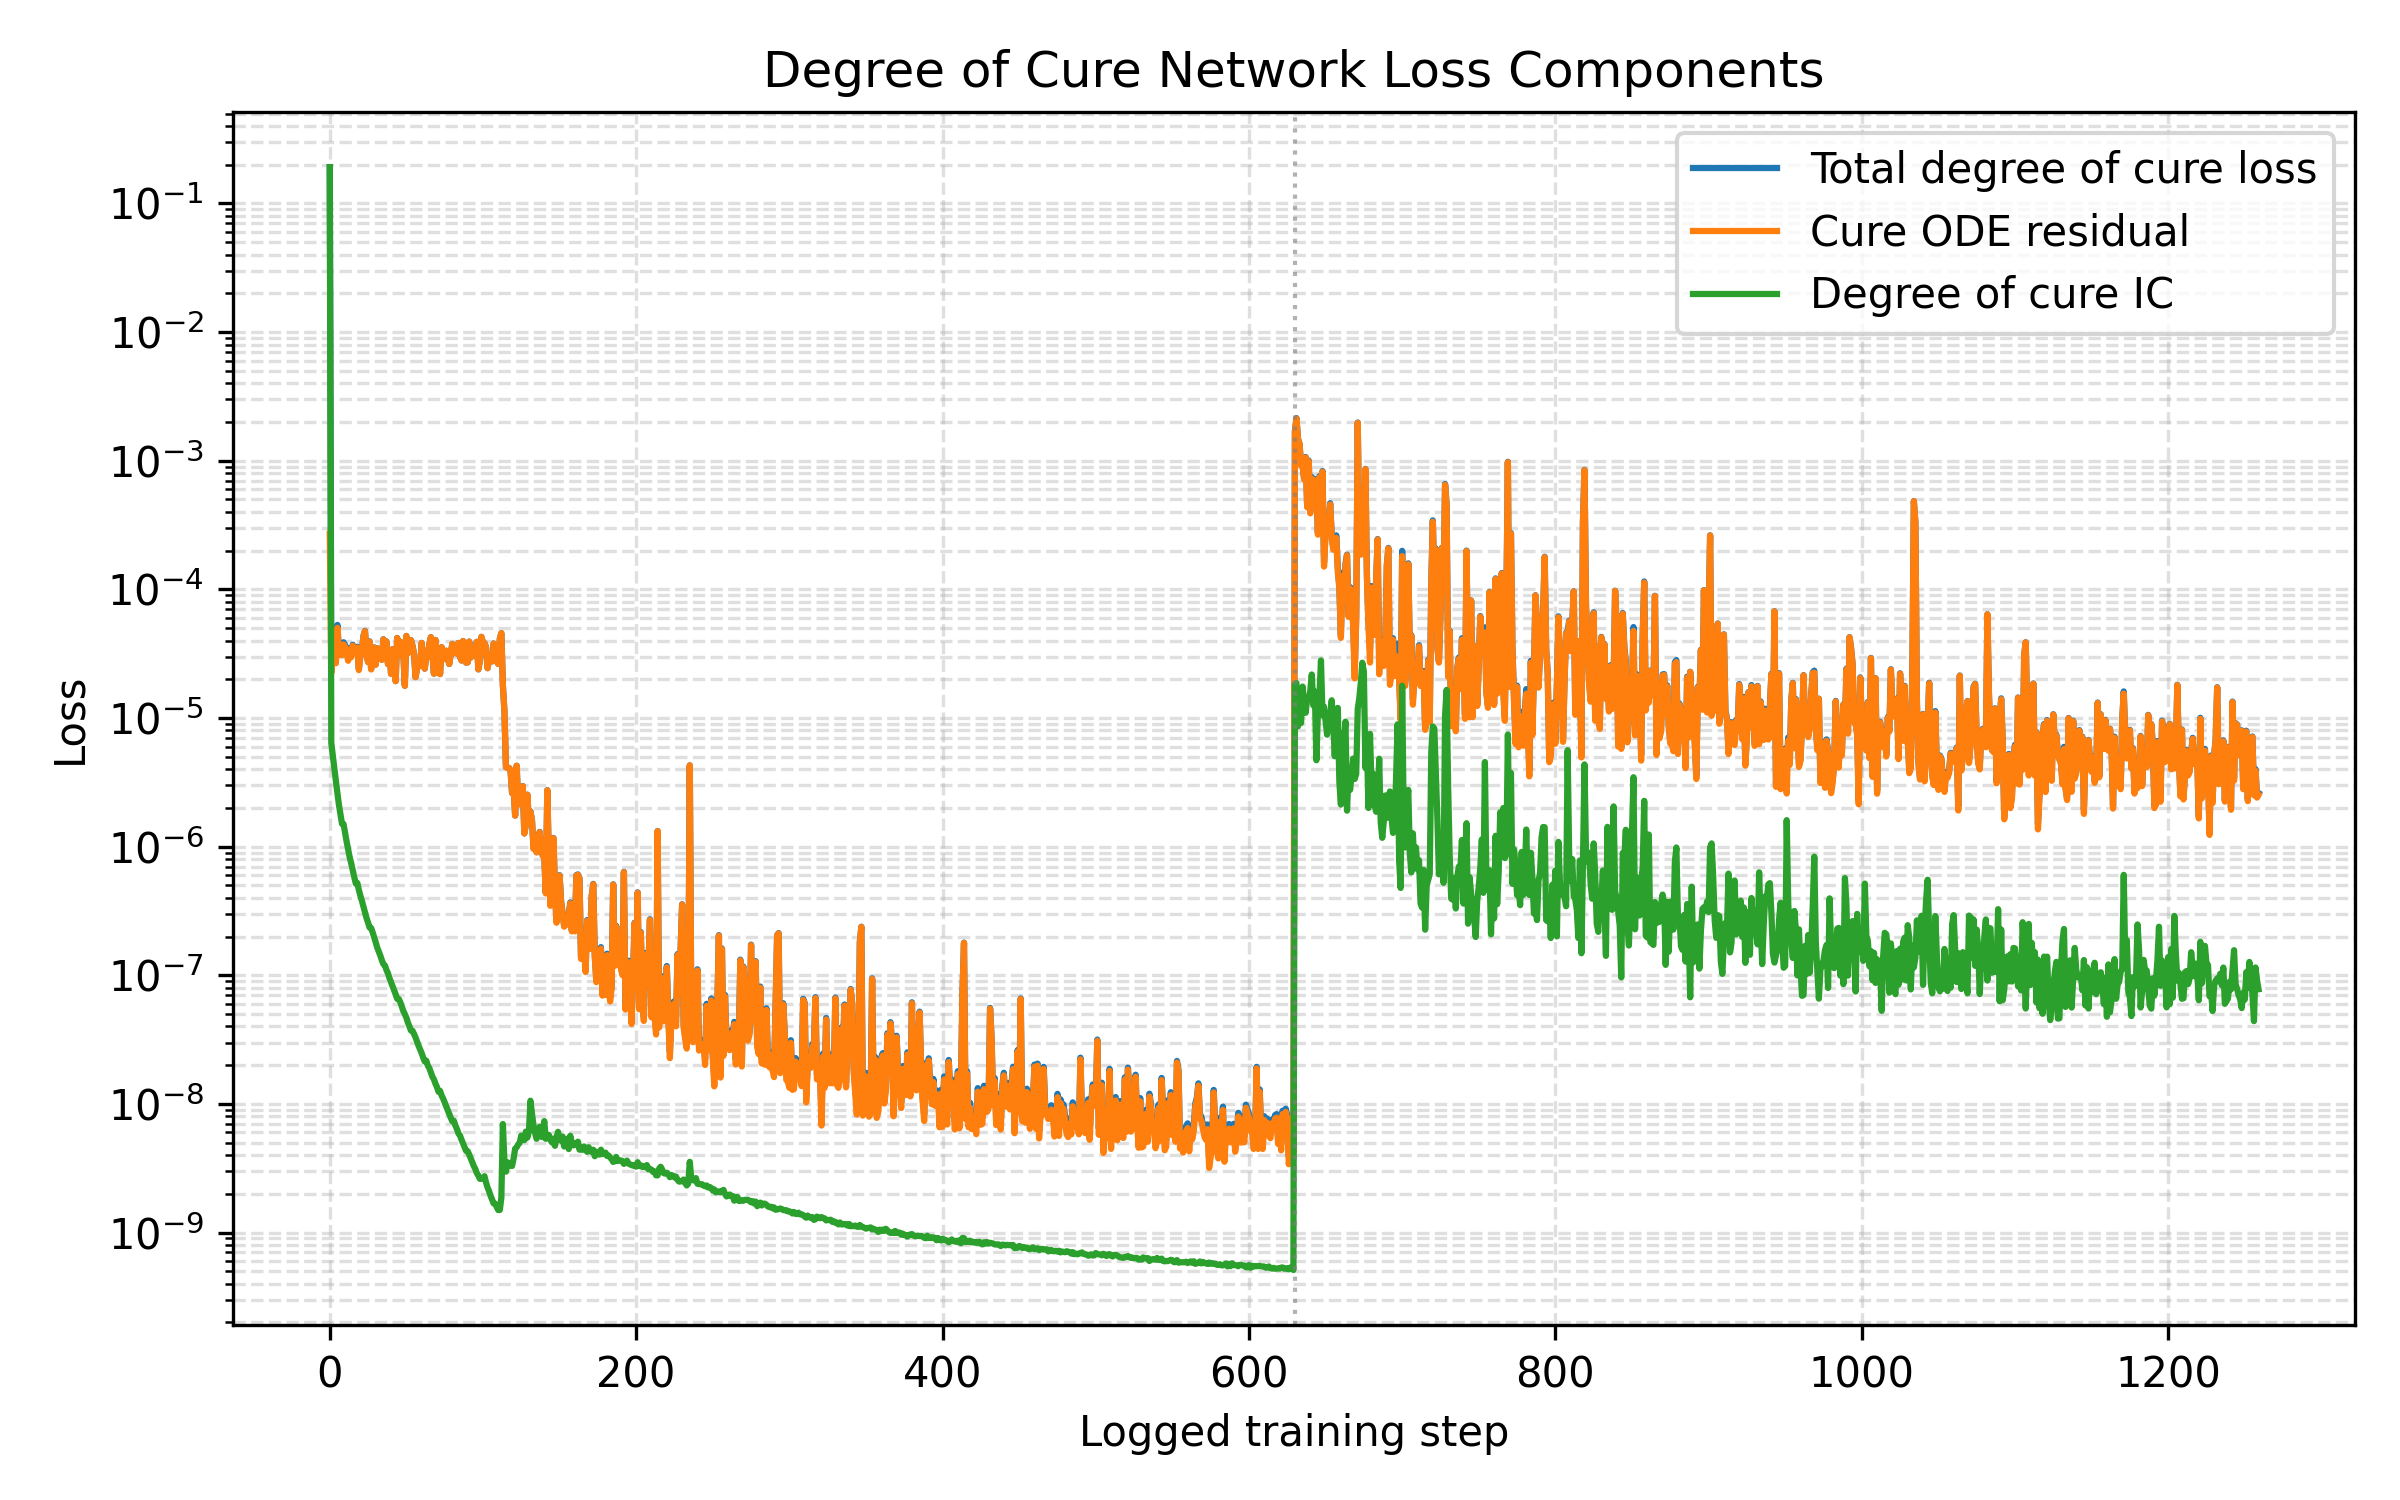

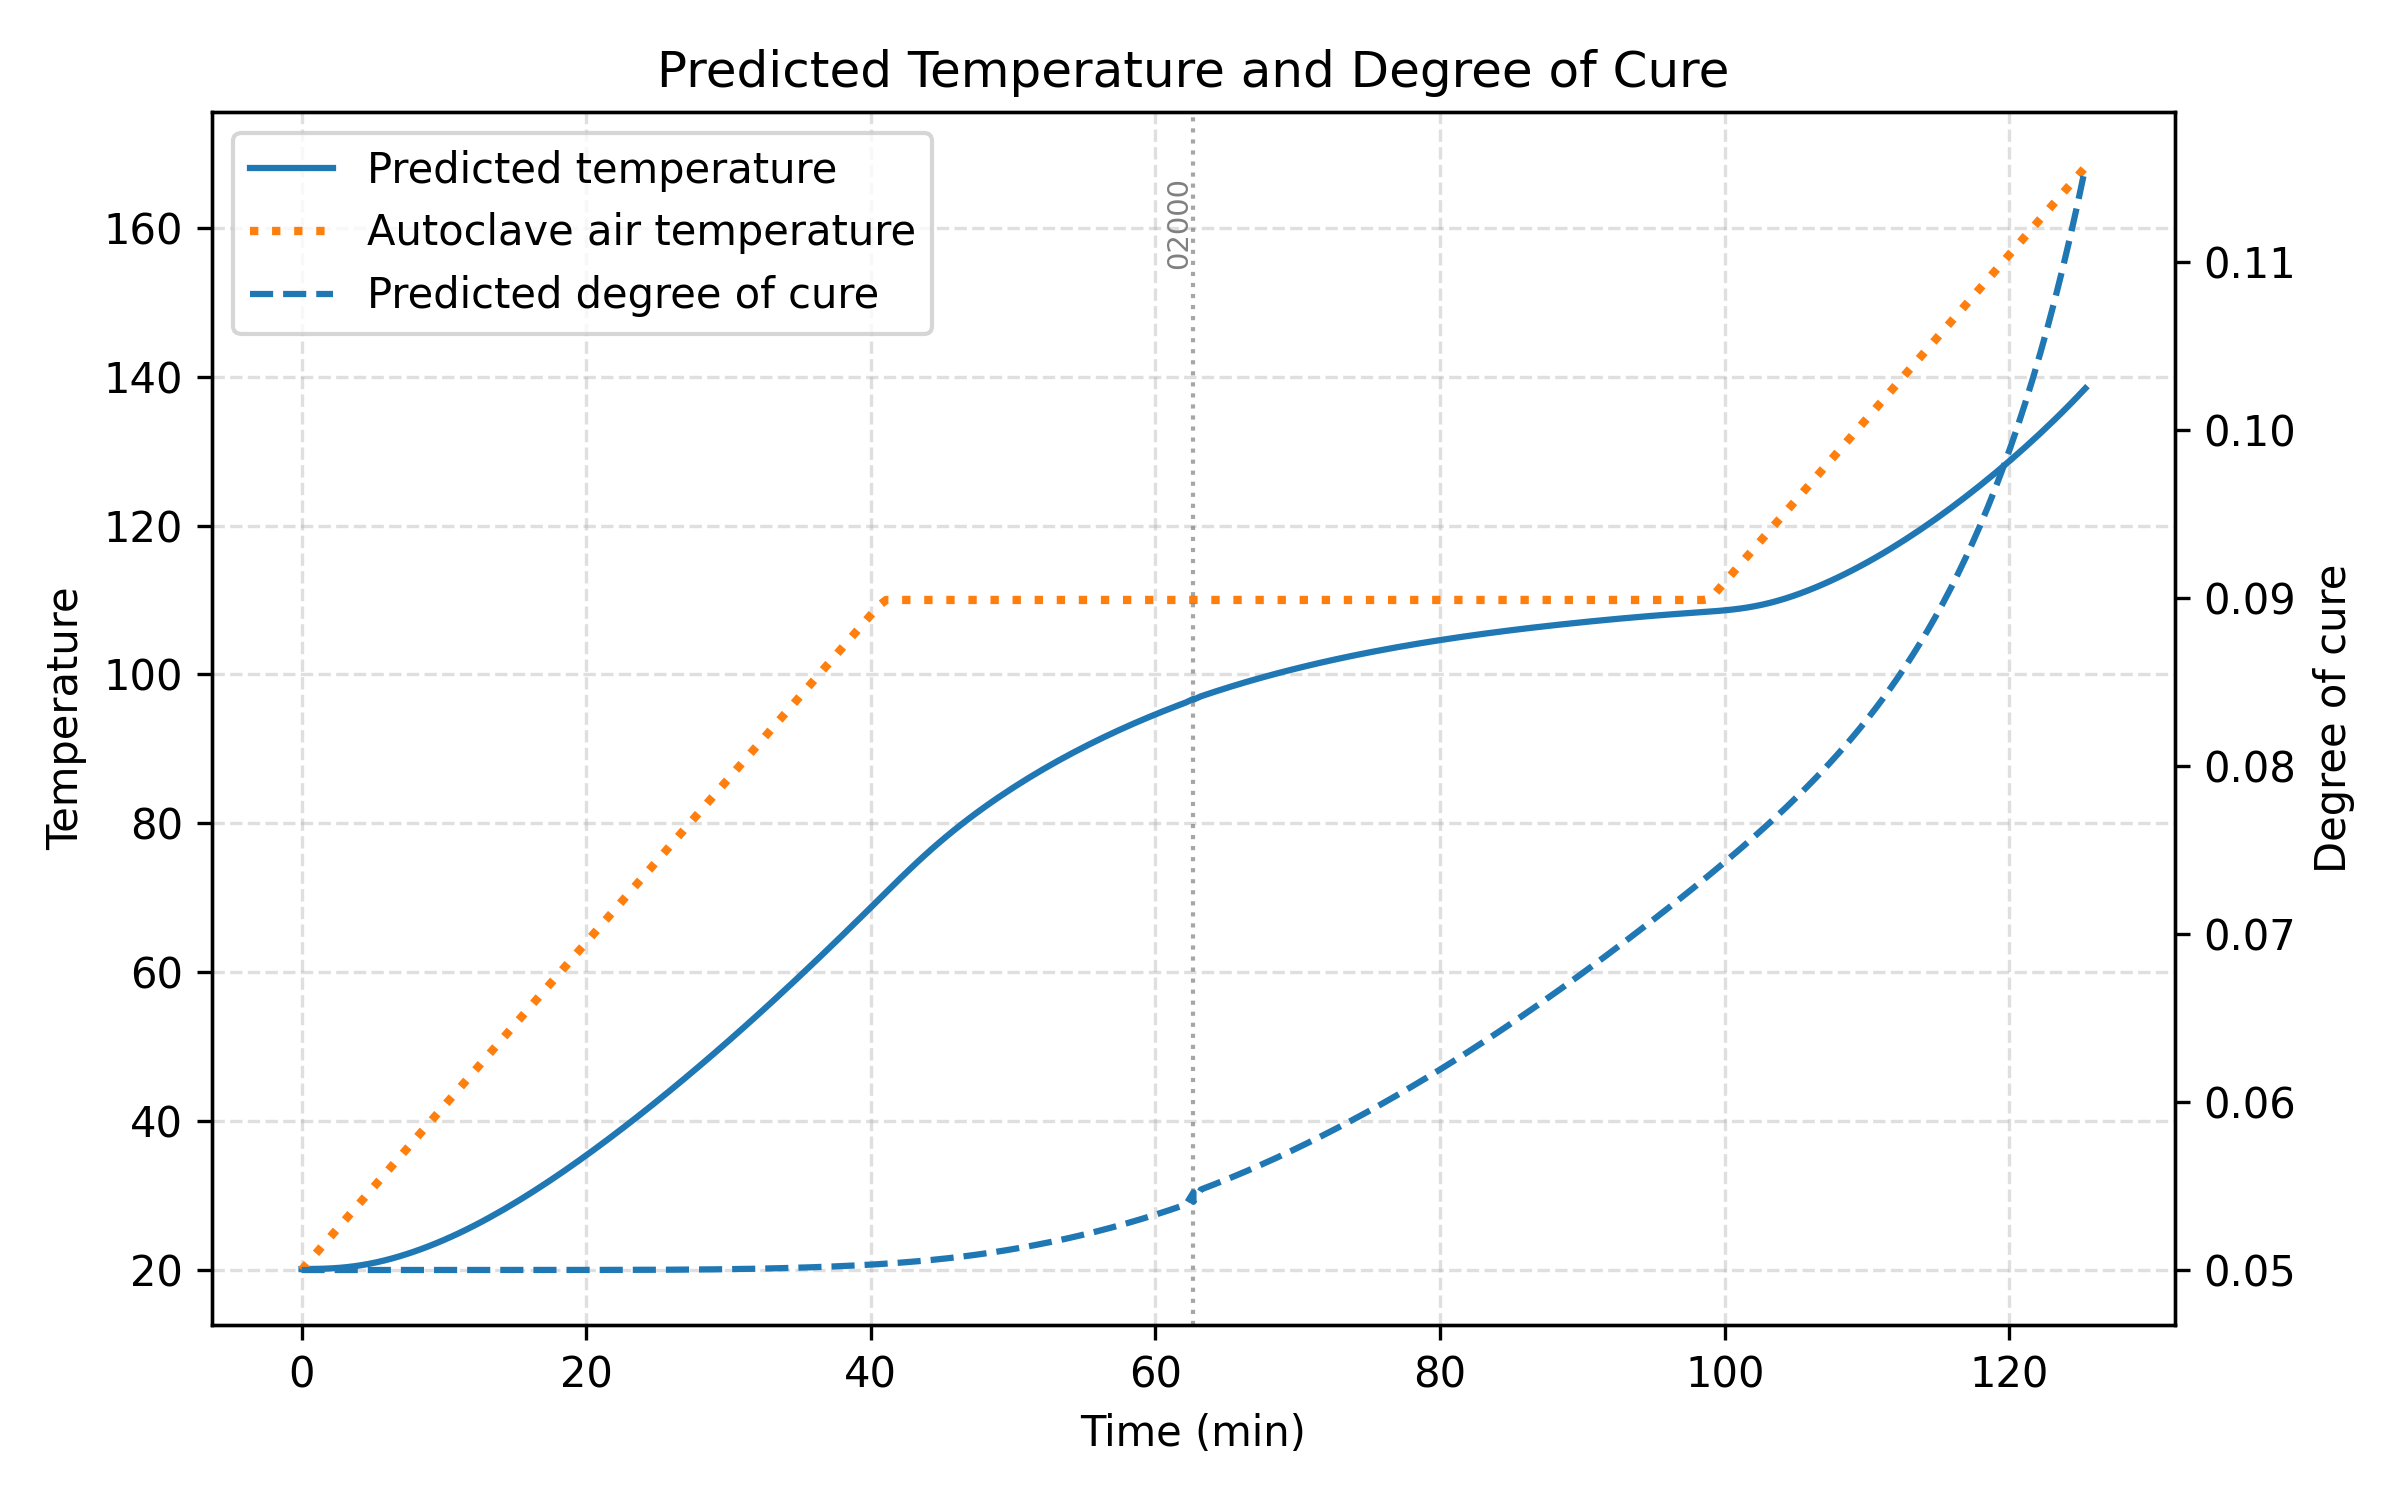

In [2]:

from IPython.display import Image, display

display(Image("outputs/figures/temperature_network_loss.png"))
display(Image("outputs/figures/doc_network_loss.png"))
display(Image("outputs/figures/final_temperature_doc_prediction.png"))

In [3]:
from pathlib import Path

print("Model tags:")
for f in sorted(Path("outputs/models").glob("xpidon_class_*_T.pkl")):
    print(f.name)

print("\nLoss files:")
for f in sorted(Path("outputs/loss_data").glob("loss_history_*.pkl")):
    print(f.name)

Model tags:
xpidon_class_02000_T.pkl
xpidon_class_04000_T.pkl

Loss files:
loss_history_02000.pkl
loss_history_04000.pkl
loss_history_merged.pkl
